<a href="https://colab.research.google.com/github/krittiyaT/Project-Group2/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ขั้นที่ 1

In [1]:
!pip install openpyxl
import pandas as pd

In [2]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 1. ติดตั้งฟอนต์ภาษาไทยลงในระบบ Colab
!apt-get -y install fonts-thai-tlwg > /dev/null 2>&1

# 2. โหลดไฟล์ฟอนต์เข้า Memory และตั้งค่า font_prop
font_path = "/usr/share/fonts/truetype/tlwg/Laksaman.ttf"
font_prop = fm.FontProperties(fname=font_path)

# 3. ตั้งค่า Default ให้ Matplotlib รู้จักฟอนต์และรองรับเครื่องหมายลบ
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# ขั้นที่ 2 — ออกแบบ Class

In [5]:
#Import และสร้าง Class
import random
from datetime import datetime, timedelta


class Book:
    def __init__(self, book_id, title, author, category_code, category_name, status="ว่าง"):
        self.book_id = book_id
        self.title = title
        self.author = author
        self.category_code = category_code
        self.category_name = category_name
        self.is_available = (status == "ว่าง")

    def borrow(self):
        """เปลี่ยนสถานะเป็นถูกยืม"""
        self.is_available = False

    def return_book(self):
        """เปลี่ยนสถานะกลับเป็นว่าง"""
        self.is_available = True


class Member:
    def __init__(self, member_id, name, member_type, loan_period_days):
        self.member_id = member_id
        self.name = name
        self.member_type = member_type
        self.loan_period_days = loan_period_days


class BookLoan:
    FINE_PER_DAY = 5

    def __init__(self, loan_id, book, member, borrow_date):
        self.loan_id = loan_id
        self.book = book
        self.member = member
        self.borrow_date = borrow_date

        self.due_date = borrow_date + timedelta(
            days=member.loan_period_days
        )

        self.return_date = None

    def calculate_late_fee(self):
        """คำนวณค่าปรับถ้าคืนช้ากว่ากำหนด"""

        if self.return_date is not None and self.return_date > self.due_date:
            late_days = (self.return_date - self.due_date).days
            return late_days * self.FINE_PER_DAY

        return 0

    def mark_returned(self, return_date):
        """บันทึกว่าคืนหนังสือแล้ว"""

        self.return_date = return_date
        self.book.return_book()

# ขั้นที่ 3 — เขียนฟังก์ชันช่วยงาน (Helper Functions)

In [50]:
import pandas as pd


def load_books(csv_path):
    """โหลดหนังสือจากไฟล์ CSV แล้วสร้างเป็น Book object"""

    df = pd.read_csv("/content/books.csv")

    return [
        Book(
            row.book_id,
            row.title,
            row.author,
            row.category_code,
            row.category_name,
            row.status
        )
        for row in df.itertuples(index=False)
    ]


def load_members(csv_path):
    """โหลดสมาชิกจากไฟล์ CSV แล้วสร้างเป็น Member object"""

    df = pd.read_csv("/content/members.csv")

    return [
        Member(
            row.member_id,
            row.name,
            row.member_type,
            row.loan_period_days
        )
        for row in df.itertuples(index=False)
    ]


def random_borrow_date(start_date, days_range=300):
    """สุ่มวันที่ยืม"""

    offset = random.randint(0, days_range)

    return start_date + timedelta(days=offset)


def decide_return_outcome(
    never_return_probability=0.20,
    late_probability=0.25
):
    """สุ่มผลการคืนหนังสือ"""

    r = random.random()

    if r < never_return_probability:
        return "not_returned"

    elif r < never_return_probability + late_probability:
        return "late"

    else:
        return "on_time"


def calculate_return_date(due_date, outcome):
    """คำนวณวันที่คืนตามผลการสุ่ม"""

    if outcome == "not_returned":
        return None

    elif outcome == "late":
        return due_date + timedelta(days=random.randint(1, 10))

    else:
        return due_date - timedelta(days=random.randint(0, 5))

# ขั้นที่ 4 — จำลองข้อมูลทีละรายการด้วย Loop

In [46]:
# จำลองการใช้บริการยืม-คืนหนังสือของนักศึกษา จำนวน 3000 คน

def borrow(loan_id, member_id, book_id, borrow_date):
    if member_id not in members.index:
        print(f"ไม่พบ member_id '{member_id}'")
        return
    if book_id not in books.index:
        print(f"ไม่พบ book_id '{book_id}'")
        return
    name = members.loc[member_id, "name"]
    title = books.loc[book_id, "title"]
    loan_period = int(members.loc[member_id, "loan_period_days"])
    due_date = borrow_date + timedelta(days=loan_period)
    print(f"{loan_id}: นักศึกษา: {name} ({member_id}) ยืมหนังสือ: {title} ({book_id}) | วันที่ยืม: {borrow_date.date()} | กำหนดคืน: {due_date.date()}")


In [45]:
# รายการที่ 0001
borrow("1", "PS0001", "D000-001", datetime(2025, 1, 1))

1: นักศึกษา: รติ (PS0001) ยืมหนังสือ: พื้นฐานการเขียนโปรแกรมด้วย Python (D000-001) | วันที่ยืม: 2025-01-01 | กำหนดคืน: 2025-01-15


In [9]:
borrow("2", "PS0002", "D000-002", datetime(2025, 1, 2))

2: นักศึกษา: กุ๊กกิ๊ก (PS0002) ยืมหนังสือ: ความรู้เบื้องต้นเกี่ยวกับปัญญาประดิษฐ์ (D000-002) | วันที่ยืม: 2025-01-02 | กำหนดคืน: 2025-01-16


In [14]:
borrow("3", "PS0003", "D000-003", datetime(2025, 1, 3))

3: นักศึกษา: เนย (PS0003) ยืมหนังสือ: ระบบฐานข้อมูลสำหรับผู้เริ่มต้น (D000-003) | วันที่ยืม: 2025-01-03 | กำหนดคืน: 2025-01-17


In [13]:
borrow("4", "PS0004", "D000-004", datetime(2025, 1, 4))

4: นักศึกษา: มิวสิค (PS0004) ยืมหนังสือ: เครือข่ายคอมพิวเตอร์และการสื่อสารข้อมูล (D000-004) | วันที่ยืม: 2025-01-04 | กำหนดคืน: 2025-01-18


In [29]:
borrow("5", "PS0005", "D000-005", datetime(2025, 1, 5))

5: นักศึกษา: ชอพอ (PS0005) ยืมหนังสือ: ความมั่นคงปลอดภัยไซเบอร์เบื้องต้น (D000-005) | วันที่ยืม: 2025-01-05 | กำหนดคืน: 2025-01-19


In [11]:
borrow("6", "PS0006", "D000-006", datetime(2025, 1, 6))

6: นักศึกษา: ต้นกล้า (PS0006) ยืมหนังสือ: การจัดการสารสนเทศในยุคดิจิทัล (D000-006) | วันที่ยืม: 2025-01-06 | กำหนดคืน: 2025-01-20


In [10]:
borrow("7", "PS0007", "D000-007", datetime(2025, 1, 7))

7: นักศึกษา: แพรวา (PS0007) ยืมหนังสือ: อัลกอริทึมและโครงสร้างข้อมูล (D000-007) | วันที่ยืม: 2025-01-07 | กำหนดคืน: 2025-01-21


In [ ]:
borrow("8", "PS0008", "D000-008", datetime(2025, 1, 8))

8: นักศึกษา: มาร์ค (PS0008) ยืมหนังสือ: คอมพิวเตอร์กราฟิกเบื้องต้น (D000-008) | วันที่ยืม: 2025-01-08 | กำหนดคืน: 2025-01-22


In [ ]:
borrow("9", "PS0009", "D000-009", datetime(2025, 1, 9))

9: นักศึกษา: ข้าวหอม (PS0009) ยืมหนังสือ: การพัฒนาเว็บไซต์สมัยใหม่ (D000-009) | วันที่ยืม: 2025-01-09 | กำหนดคืน: 2025-01-23


In [ ]:
borrow("10", "PS0010", "D000-010", datetime(2025, 1, 10))

10: นักศึกษา: ไทเกอร์ (PS0010) ยืมหนังสือ: ห้องสมุดดิจิทัลและการจัดเก็บข้อมูล (D000-010) | วันที่ยืม: 2025-01-10 | กำหนดคืน: 2025-01-24


In [ ]:
borrow("11", "PS0011", "D000-011", datetime(2025, 1, 11))

11: นักศึกษา: พอยท์ (PS0011) ยืมหนังสือ: ความรู้ทั่วไปเกี่ยวกับเทคโนโลยีสารสนเทศ (D000-011) | วันที่ยืม: 2025-01-11 | กำหนดคืน: 2025-01-25


In [30]:
borrow("12", "PS0012", "D000-012", datetime(2025, 1, 12))

12: นักศึกษา: น้ำฟ้า (PS0012) ยืมหนังสือ: คลาวด์คอมพิวติ้งเบื้องต้น (D000-012) | วันที่ยืม: 2025-01-12 | กำหนดคืน: 2025-01-26


In [ ]:
borrow("13", "PS0013", "D000-013", datetime(2025, 1, 13))

13: นักศึกษา: วิน (PS0013) ยืมหนังสือ: การเขียนโปรแกรมเชิงวัตถุ (D000-013) | วันที่ยืม: 2025-01-13 | กำหนดคืน: 2025-01-27


In [31]:
borrow("14", "PS0014", "D000-014", datetime(2025, 1, 14))

14: นักศึกษา: มะนาว (PS0014) ยืมหนังสือ: วิทยาการข้อมูลเบื้องต้น (D000-014) | วันที่ยืม: 2025-01-14 | กำหนดคืน: 2025-01-28


In [ ]:
borrow("15", "PS0015", "D000-015", datetime(2025, 1, 15))

15: นักศึกษา: ออกัส (PS0015) ยืมหนังสือ: สารานุกรมความรู้รอบตัว เล่ม 1 (D000-015) | วันที่ยืม: 2025-01-15 | กำหนดคืน: 2025-01-29


In [ ]:
borrow("16", "PS0016", "D100-001", datetime(2025, 1, 16))

16: นักศึกษา: บุ๊ค (PS0016) ยืมหนังสือ: ปรัชญากรีกโบราณ (D100-001) | วันที่ยืม: 2025-01-16 | กำหนดคืน: 2025-01-30


In [ ]:
borrow("17", "PS0017", "D100-002", datetime(2025, 1, 17))

17: นักศึกษา: ภูเขา (PS0017) ยืมหนังสือ: จิตวิทยาเบื้องต้น (D100-002) | วันที่ยืม: 2025-01-17 | กำหนดคืน: 2025-01-31


In [ ]:
borrow("18", "PS0018", "D100-003", datetime(2025, 1, 18))

18: นักศึกษา: เจน (PS0018) ยืมหนังสือ: ตรรกศาสตร์และการให้เหตุผล (D100-003) | วันที่ยืม: 2025-01-18 | กำหนดคืน: 2025-02-01


In [ ]:
borrow("19", "PS0019", "D100-004", datetime(2025, 1, 19))

19: นักศึกษา: แสนดี (PS0019) ยืมหนังสือ: ปรัชญาตะวันออก (D100-004) | วันที่ยืม: 2025-01-19 | กำหนดคืน: 2025-02-02


In [ ]:
borrow("20", "PS0020", "D100-005", datetime(2025, 1, 20))

20: นักศึกษา: ลีโอ (PS0020) ยืมหนังสือ: จิตวิทยาการพัฒนาตนเอง (D100-005) | วันที่ยืม: 2025-01-20 | กำหนดคืน: 2025-02-03


In [ ]:
borrow("21", "PS0021", "D100-006", datetime(2025, 1, 21))

21: นักศึกษา: ฝุ่น (PS0021) ยืมหนังสือ: ความคิดเชิงวิพากษ์ (D100-006) | วันที่ยืม: 2025-01-21 | กำหนดคืน: 2025-02-04


In [ ]:
borrow("22", "PS0022", "D100-007", datetime(2025, 1, 22))

22: นักศึกษา: จัสมิน (PS0022) ยืมหนังสือ: ปรัชญาการเมืองเบื้องต้น (D100-007) | วันที่ยืม: 2025-01-22 | กำหนดคืน: 2025-02-05


In [ ]:
borrow("23", "PS0023", "D100-008", datetime(2025, 1, 23))

23: นักศึกษา: สายชล (PS0023) ยืมหนังสือ: จิตวิทยาสังคม (D100-008) | วันที่ยืม: 2025-01-23 | กำหนดคืน: 2025-02-06


In [ ]:
borrow("24", "PS0024", "D100-009", datetime(2025, 1, 24))

24: นักศึกษา: อาร์ม (PS0024) ยืมหนังสือ: อภิปรัชญาและญาณวิทยา (D100-009) | วันที่ยืม: 2025-01-24 | กำหนดคืน: 2025-02-07


In [ ]:
borrow("25", "PS0025", "D100-010", datetime(2025, 1, 25))

25: นักศึกษา: ชมพู่ (PS0025) ยืมหนังสือ: จิตวิทยาการเรียนรู้ (D100-010) | วันที่ยืม: 2025-01-25 | กำหนดคืน: 2025-02-08


In [ ]:
borrow("26", "PS0026", "D100-011", datetime(2025, 1, 26))

26: นักศึกษา: คอปเตอร์ (PS0026) ยืมหนังสือ: ปรัชญาชีวิตและความสุข (D100-011) | วันที่ยืม: 2025-01-26 | กำหนดคืน: 2025-02-09


In [ ]:
borrow("27", "PS0027", "D100-012", datetime(2025, 1, 27))

27: นักศึกษา: เพชร (PS0027) ยืมหนังสือ: จิตวิทยาองค์กร (D100-012) | วันที่ยืม: 2025-01-27 | กำหนดคืน: 2025-02-10


In [ ]:
borrow("28", "PS0028", "D100-013", datetime(2025, 1, 28))

28: นักศึกษา: มีน (PS0028) ยืมหนังสือ: ปรัชญาตะวันตกสมัยใหม่ (D100-013) | วันที่ยืม: 2025-01-28 | กำหนดคืน: 2025-02-11


In [ ]:
borrow("29", "PS0029", "D100-014", datetime(2025, 1, 29))

29: นักศึกษา: ส้มจี๊ด (PS0029) ยืมหนังสือ: จิตวิเคราะห์เบื้องต้น (D100-014) | วันที่ยืม: 2025-01-29 | กำหนดคืน: 2025-02-12


In [ ]:
borrow("30", "PS0030", "D100-015", datetime(2025, 1, 30))

30: นักศึกษา: บอส (PS0030) ยืมหนังสือ: การคิดอย่างเป็นระบบ (D100-015) | วันที่ยืม: 2025-01-30 | กำหนดคืน: 2025-02-13


In [ ]:
borrow("31", "PS0031", "D200-001", datetime(2025, 1, 31))

31: นักศึกษา: น้ำขิง (PS0031) ยืมหนังสือ: พุทธประวัติฉบับย่อ (D200-001) | วันที่ยืม: 2025-01-31 | กำหนดคืน: 2025-02-14


In [ ]:
borrow("32", "PS0032", "D200-002", datetime(2025, 2, 1))

32: นักศึกษา: กาย (PS0032) ยืมหนังสือ: หลักธรรมในชีวิตประจำวัน (D200-002) | วันที่ยืม: 2025-02-01 | กำหนดคืน: 2025-02-15


In [ ]:
borrow("33", "PS0033", "D200-003", datetime(2025, 2, 2))

33: นักศึกษา: ใยบัว (PS0033) ยืมหนังสือ: ศาสนาเปรียบเทียบ (D200-003) | วันที่ยืม: 2025-02-02 | กำหนดคืน: 2025-02-16


In [ ]:
borrow("34", "PS0034", "D200-004", datetime(2025, 2, 3))

34: นักศึกษา: โอโซน (PS0034) ยืมหนังสือ: ประวัติศาสตร์ศาสนาคริสต์ (D200-004) | วันที่ยืม: 2025-02-03 | กำหนดคืน: 2025-02-17


In [ ]:
borrow("35", "PS0035", "D200-005", datetime(2025, 2, 4))

35: นักศึกษา: ปลายฟ้า (PS0035) ยืมหนังสือ: อิสลามศึกษาเบื้องต้น (D200-005) | วันที่ยืม: 2025-02-04 | กำหนดคืน: 2025-02-18


In [ ]:
borrow("36", "PS0036", "D200-006", datetime(2025, 2, 5))

36: นักศึกษา: แม็กซ์ (PS0036) ยืมหนังสือ: ปรัชญาพุทธศาสนา (D200-006) | วันที่ยืม: 2025-02-05 | กำหนดคืน: 2025-02-19


In [ ]:
borrow("37", "PS0037", "D200-007", datetime(2025, 2, 6))

37: นักศึกษา: ต้นน้ำ (PS0037) ยืมหนังสือ: ศาสนาพราหมณ์-ฮินดู (D200-007) | วันที่ยืม: 2025-02-06 | กำหนดคืน: 2025-02-20


In [ ]:
borrow("38", "PS0038", "D200-008", datetime(2025, 2, 7))

38: นักศึกษา: แป้ง (PS0038) ยืมหนังสือ: จริยธรรมและศีลธรรม (D200-008) | วันที่ยืม: 2025-02-07 | กำหนดคืน: 2025-02-21


In [ ]:
borrow("39", "PS0039", "D200-009", datetime(2025, 2, 8))

39: นักศึกษา: มิกกี้ (PS0039) ยืมหนังสือ: พิธีกรรมและประเพณีทางศาสนา (D200-009) | วันที่ยืม: 2025-02-08 | กำหนดคืน: 2025-02-22


In [ ]:
borrow("40", "PS0040", "D200-010", datetime(2025, 2, 9))

40: นักศึกษา: ทะเล (PS0040) ยืมหนังสือ: การทำสมาธิเพื่อความสงบ (D200-010) | วันที่ยืม: 2025-02-09 | กำหนดคืน: 2025-02-23


In [ ]:
borrow("41", "PS0041", "D200-011", datetime(2025, 2, 10))

41: นักศึกษา: ยูโร (PS0041) ยืมหนังสือ: ศาสนากับสังคมไทย (D200-011) | วันที่ยืม: 2025-02-10 | กำหนดคืน: 2025-02-24


In [ ]:
borrow("42", "PS0042", "D200-012", datetime(2025, 2, 11))

42: นักศึกษา: ฟรัง (PS0042) ยืมหนังสือ: คัมภีร์และวรรณกรรมทางศาสนา (D200-012) | วันที่ยืม: 2025-02-11 | กำหนดคืน: 2025-02-25


In [ ]:
borrow("43", "PS0043", "D200-013", datetime(2025, 2, 12))

43: นักศึกษา: พาย (PS0043) ยืมหนังสือ: เซนและปรัชญาญี่ปุ่น (D200-013) | วันที่ยืม: 2025-02-12 | กำหนดคืน: 2025-02-26


In [ ]:
borrow("44", "PS0044", "D200-014", datetime(2025, 2, 13))

44: นักศึกษา: ธันวา (PS0044) ยืมหนังสือ: ศาสนาซิกข์เบื้องต้น (D200-014) | วันที่ยืม: 2025-02-13 | กำหนดคืน: 2025-02-27


In [ ]:
borrow("45", "PS0045", "D200-015", datetime(2025, 2, 14))

45: นักศึกษา: โซล (PS0045) ยืมหนังสือ: จริยศาสตร์ทางศาสนา (D200-015) | วันที่ยืม: 2025-02-14 | กำหนดคืน: 2025-02-28


In [ ]:
borrow("46", "PS0046", "D300-001", datetime(2025, 2, 15))

46: นักศึกษา: มุก (PS0046) ยืมหนังสือ: สังคมวิทยาเบื้องต้น (D300-001) | วันที่ยืม: 2025-02-15 | กำหนดคืน: 2025-03-01


In [ ]:
borrow("47", "PS0047", "D300-002", datetime(2025, 2, 16))

47: นักศึกษา: เจมส์ (PS0047) ยืมหนังสือ: รัฐศาสตร์เบื้องต้น (D300-002) | วันที่ยืม: 2025-02-16 | กำหนดคืน: 2025-03-02


In [ ]:
borrow("48", "PS0048", "D300-003", datetime(2025, 2, 17))

48: นักศึกษา: ผิงผิง (PS0048) ยืมหนังสือ: เศรษฐศาสตร์เพื่อชีวิตประจำวัน (D300-003) | วันที่ยืม: 2025-02-17 | กำหนดคืน: 2025-03-03


In [ ]:
borrow("49", "PS0049", "D300-004", datetime(2025, 2, 18))

49: นักศึกษา: เควิน (PS0049) ยืมหนังสือ: กฎหมายเบื้องต้นสำหรับประชาชน (D300-004) | วันที่ยืม: 2025-02-18 | กำหนดคืน: 2025-03-04


In [ ]:
borrow("50", "PS0050", "D300-005", datetime(2025, 2, 19))

50: นักศึกษา: เมฆ (PS0050) ยืมหนังสือ: มานุษยวิทยาเบื้องต้น (D300-005) | วันที่ยืม: 2025-02-19 | กำหนดคืน: 2025-03-05


In [ ]:
borrow("51", "PS0051", "D300-006", datetime(2025, 2, 20))

51: นักศึกษา: มิ้นท์ (PS0051) ยืมหนังสือ: การศึกษาและการพัฒนาสังคม (D300-006) | วันที่ยืม: 2025-02-20 | กำหนดคืน: 2025-03-06


In [ ]:
borrow("52", "PS0052", "D300-007", datetime(2025, 2, 21))

52: นักศึกษา: ออสติน (PS0052) ยืมหนังสือ: สื่อสารมวลชนในยุคดิจิทัล (D300-007) | วันที่ยืม: 2025-02-21 | กำหนดคืน: 2025-03-07


In [ ]:
borrow("53", "PS0053", "D300-008", datetime(2025, 2, 22))

53: นักศึกษา: ปั้นสิบ (PS0053) ยืมหนังสือ: ประชากรศาสตร์เบื้องต้น (D300-008) | วันที่ยืม: 2025-02-22 | กำหนดคืน: 2025-03-08


In [ ]:
borrow("54", "PS0054", "D300-009", datetime(2025, 2, 23))

54: นักศึกษา: เบียร์ (PS0054) ยืมหนังสือ: การปกครองท้องถิ่นไทย (D300-009) | วันที่ยืม: 2025-02-23 | กำหนดคืน: 2025-03-09


In [ ]:
borrow("55", "PS0055", "D300-010", datetime(2025, 2, 24))

55: นักศึกษา: ถ้วยฟู (PS0055) ยืมหนังสือ: สิทธิมนุษยชนเบื้องต้น (D300-010) | วันที่ยืม: 2025-02-24 | กำหนดคืน: 2025-03-10


In [ ]:
borrow("56", "PS0056", "D300-011", datetime(2025, 2, 25))

56: นักศึกษา: ดรีม (PS0056) ยืมหนังสือ: เพศสภาพและสังคม (D300-011) | วันที่ยืม: 2025-02-25 | กำหนดคืน: 2025-03-11


In [ ]:
borrow("57", "PS0057", "D300-012", datetime(2025, 2, 26))

57: นักศึกษา: ข้าวปั้น (PS0057) ยืมหนังสือ: อาชญาวิทยาเบื้องต้น (D300-012) | วันที่ยืม: 2025-02-26 | กำหนดคืน: 2025-03-12


In [ ]:
borrow("58", "PS0058", "D300-013", datetime(2025, 2, 27))

58: นักศึกษา: ท๊อป (PS0058) ยืมหนังสือ: การพัฒนาชุมชน (D300-013) | วันที่ยืม: 2025-02-27 | กำหนดคืน: 2025-03-13


In [ ]:
borrow("59", "PS0059", "D300-014", datetime(2025, 2, 28))

59: นักศึกษา: สายฝน (PS0059) ยืมหนังสือ: เศรษฐกิจพอเพียง (D300-014) | วันที่ยืม: 2025-02-28 | กำหนดคืน: 2025-03-14


In [ ]:
borrow("60", "PS0060", "D300-015", datetime(2025, 3, 1))

60: นักศึกษา: ไนซ์ (PS0060) ยืมหนังสือ: ความสัมพันธ์ระหว่างประเทศ (D300-015) | วันที่ยืม: 2025-03-01 | กำหนดคืน: 2025-03-15


In [ ]:
borrow("61", "PS0061", "D400-001", datetime(2025, 3, 2))

61: นักศึกษา: ออมสิน (PS0061) ยืมหนังสือ: ภาษาศาสตร์เบื้องต้น (D400-001) | วันที่ยืม: 2025-03-02 | กำหนดคืน: 2025-03-16


In [ ]:
borrow("62", "PS0062", "D400-002", datetime(2025, 3, 3))

62: นักศึกษา: ปาล์ม (PS0062) ยืมหนังสือ: ไวยากรณ์ภาษาอังกฤษเพื่อการสื่อสาร (D400-002) | วันที่ยืม: 2025-03-03 | กำหนดคืน: 2025-03-17


In [ ]:
borrow("63", "PS0063", "D400-003", datetime(2025, 3, 4))

63: นักศึกษา: ก้านพลู (PS0063) ยืมหนังสือ: ภาษาไทยเพื่อการสื่อสาร (D400-003) | วันที่ยืม: 2025-03-04 | กำหนดคืน: 2025-03-18


In [ ]:
borrow("64", "PS0064", "D400-004", datetime(2025, 3, 5))

64: นักศึกษา: ไบร์ท (PS0064) ยืมหนังสือ: การแปลภาษาเบื้องต้น (D400-004) | วันที่ยืม: 2025-03-05 | กำหนดคืน: 2025-03-19


In [ ]:
borrow("65", "PS0065", "D400-005", datetime(2025, 3, 6))

65: นักศึกษา: ปาง (PS0065) ยืมหนังสือ: ภาษาศาสตร์สังคม (D400-005) | วันที่ยืม: 2025-03-06 | กำหนดคืน: 2025-03-20


In [ ]:
borrow("66", "PS0066", "D400-006", datetime(2025, 3, 7))

66: นักศึกษา: ฟลุ๊ค (PS0066) ยืมหนังสือ: สัทศาสตร์และสัทวิทยา (D400-006) | วันที่ยืม: 2025-03-07 | กำหนดคืน: 2025-03-21


In [ ]:
borrow("67", "PS0067", "D400-007", datetime(2025, 3, 8))

67: นักศึกษา: น้ำหวาน (PS0067) ยืมหนังสือ: ภาษาจีนเพื่อการสื่อสาร (D400-007) | วันที่ยืม: 2025-03-08 | กำหนดคืน: 2025-03-22


In [ ]:
borrow("68", "PS0068", "D400-008", datetime(2025, 3, 9))

68: นักศึกษา: นัท (PS0068) ยืมหนังสือ: ภาษาญี่ปุ่นเบื้องต้น (D400-008) | วันที่ยืม: 2025-03-09 | กำหนดคืน: 2025-03-23


In [ ]:
borrow("69", "PS0069", "D400-009", datetime(2025, 3, 10))

69: นักศึกษา: แก้มใส (PS0069) ยืมหนังสือ: ประวัติศาสตร์ภาษาไทย (D400-009) | วันที่ยืม: 2025-03-10 | กำหนดคืน: 2025-03-24


In [ ]:
borrow("70", "PS0070", "D400-010", datetime(2025, 3, 11))

70: นักศึกษา: ทิวเขา (PS0070) ยืมหนังสือ: ภาษาศาสตร์เชิงคอมพิวเตอร์ (D400-010) | วันที่ยืม: 2025-03-11 | กำหนดคืน: 2025-03-25


In [ ]:
borrow("71", "PS0071", "D400-011", datetime(2025, 3, 12))

71: นักศึกษา: อะตอม (PS0071) ยืมหนังสือ: การเขียนเชิงวิชาการ (D400-011) | วันที่ยืม: 2025-03-12 | กำหนดคืน: 2025-03-26


In [ ]:
borrow("72", "PS0072", "D400-012", datetime(2025, 3, 13))

72: นักศึกษา: แบมแบม (PS0072) ยืมหนังสือ: ภาษาเกาหลีสำหรับผู้เริ่มต้น (D400-012) | วันที่ยืม: 2025-03-13 | กำหนดคืน: 2025-03-27


In [ ]:
borrow("73", "PS0073", "D400-013", datetime(2025, 3, 14))

73: นักศึกษา: ตะวัน (PS0073) ยืมหนังสือ: วัจนลีลาศาสตร์ (D400-013) | วันที่ยืม: 2025-03-14 | กำหนดคืน: 2025-03-28


In [ ]:
borrow("74", "PS0074", "D400-014", datetime(2025, 3, 15))

74: นักศึกษา: คริส (PS0074) ยืมหนังสือ: ภาษาฝรั่งเศสเบื้องต้น (D400-014) | วันที่ยืม: 2025-03-15 | กำหนดคืน: 2025-03-29


In [ ]:
borrow("75", "PS0075", "D400-015", datetime(2025, 3, 16))

75: นักศึกษา: ยิ้ม (PS0075) ยืมหนังสือ: พจนานุกรมศัพท์ทางวิชาการ (D400-015) | วันที่ยืม: 2025-03-16 | กำหนดคืน: 2025-03-30


In [ ]:
borrow("76", "PS0076", "D500-001", datetime(2025, 3, 17))

76: นักศึกษา: ไอซ์ (PS0076) ยืมหนังสือ: ฟิสิกส์เบื้องต้น (D500-001) | วันที่ยืม: 2025-03-17 | กำหนดคืน: 2025-03-31


In [ ]:
borrow("77", "PS0077", "D500-002", datetime(2025, 3, 18))

77: นักศึกษา: ข้าวสวย (PS0077) ยืมหนังสือ: เคมีทั่วไป (D500-002) | วันที่ยืม: 2025-03-18 | กำหนดคืน: 2025-04-01


In [ ]:
borrow("78", "PS0078", "D500-003", datetime(2025, 3, 19))

78: นักศึกษา: พอร์ช (PS0078) ยืมหนังสือ: ชีววิทยาเบื้องต้น (D500-003) | วันที่ยืม: 2025-03-19 | กำหนดคืน: 2025-04-02


In [ ]:
borrow("79", "PS0079", "D500-004", datetime(2025, 3, 20))

79: นักศึกษา: ฝันดี (PS0079) ยืมหนังสือ: ดาราศาสตร์และจักรวาล (D500-004) | วันที่ยืม: 2025-03-20 | กำหนดคืน: 2025-04-03


In [ ]:
borrow("80", "PS0080", "D500-005", datetime(2025, 3, 21))

80: นักศึกษา: ไม้ที (PS0080) ยืมหนังสือ: คณิตศาสตร์พื้นฐาน (D500-005) | วันที่ยืม: 2025-03-21 | กำหนดคืน: 2025-04-04


In [ ]:
borrow("81", "PS0081", "D500-006", datetime(2025, 3, 22))

81: นักศึกษา: พลอย (PS0081) ยืมหนังสือ: ธรณีวิทยาเบื้องต้น (D500-006) | วันที่ยืม: 2025-03-22 | กำหนดคืน: 2025-04-05


In [ ]:
borrow("82", "PS0082", "D500-007", datetime(2025, 3, 23))

82: นักศึกษา: จูเนียร์ (PS0082) ยืมหนังสือ: นิเวศวิทยาและสิ่งแวดล้อม (D500-007) | วันที่ยืม: 2025-03-23 | กำหนดคืน: 2025-04-06


In [ ]:
borrow("83", "PS0083", "D500-008", datetime(2025, 3, 24))

83: นักศึกษา: มะลิ (PS0083) ยืมหนังสือ: พันธุศาสตร์เบื้องต้น (D500-008) | วันที่ยืม: 2025-03-24 | กำหนดคืน: 2025-04-07


In [ ]:
borrow("84", "PS0084", "D500-009", datetime(2025, 3, 25))

84: นักศึกษา: บาส (PS0084) ยืมหนังสือ: สถิติเพื่อการวิจัย (D500-009) | วันที่ยืม: 2025-03-25 | กำหนดคืน: 2025-04-08


In [ ]:
borrow("85", "PS0085", "D500-010", datetime(2025, 3, 26))

85: นักศึกษา: พรีม (PS0085) ยืมหนังสือ: วิทยาศาสตร์โลกและอวกาศ (D500-010) | วันที่ยืม: 2025-03-26 | กำหนดคืน: 2025-04-09


In [ ]:
borrow("86", "PS0086", "D500-011", datetime(2025, 3, 27))

86: นักศึกษา: อิกคิว (PS0086) ยืมหนังสือ: เคมีอินทรีย์เบื้องต้น (D500-011) | วันที่ยืม: 2025-03-27 | กำหนดคืน: 2025-04-10


In [ ]:
borrow("87", "PS0087", "D500-012", datetime(2025, 3, 28))

87: นักศึกษา: ต้นข้าว (PS0087) ยืมหนังสือ: ฟิสิกส์ควอนตัมเบื้องต้น (D500-012) | วันที่ยืม: 2025-03-28 | กำหนดคืน: 2025-04-11


In [ ]:
borrow("88", "PS0088", "D500-013", datetime(2025, 3, 29))

88: นักศึกษา: ฟิล์ม (PS0088) ยืมหนังสือ: สัตววิทยาเบื้องต้น (D500-013) | วันที่ยืม: 2025-03-29 | กำหนดคืน: 2025-04-12


In [ ]:
borrow("89", "PS0089", "D500-014", datetime(2025, 3, 30))

89: นักศึกษา: ชมพู (PS0089) ยืมหนังสือ: พฤกษศาสตร์เบื้องต้น (D500-014) | วันที่ยืม: 2025-03-30 | กำหนดคืน: 2025-04-13


In [ ]:
borrow("90", "PS0090", "D500-015", datetime(2025, 3, 31))

90: นักศึกษา: นนท์ (PS0090) ยืมหนังสือ: วิทยาศาสตร์สิ่งแวดล้อม (D500-015) | วันที่ยืม: 2025-03-31 | กำหนดคืน: 2025-04-14


In [ ]:
borrow("91", "PS0091", "D600-001", datetime(2025, 4, 1))

91: นักศึกษา: ใยหม่อน (PS0091) ยืมหนังสือ: วิศวกรรมเครื่องกลเบื้องต้น (D600-001) | วันที่ยืม: 2025-04-01 | กำหนดคืน: 2025-04-15


In [ ]:
borrow("92", "PS0092", "D600-002", datetime(2025, 4, 2))

92: นักศึกษา: ชอปเปอร์ (PS0092) ยืมหนังสือ: การแพทย์เบื้องต้นสำหรับประชาชน (D600-002) | วันที่ยืม: 2025-04-02 | กำหนดคืน: 2025-04-16


In [ ]:
borrow("93", "PS0093", "D600-003", datetime(2025, 4, 3))

93: นักศึกษา: เพียงออ (PS0093) ยืมหนังสือ: เกษตรกรรมยุคใหม่ (D600-003) | วันที่ยืม: 2025-04-03 | กำหนดคืน: 2025-04-17


In [ ]:
borrow("94", "PS0094", "D600-004", datetime(2025, 4, 4))

94: นักศึกษา: เบนซ์ (PS0094) ยืมหนังสือ: วิศวกรรมไฟฟ้าเบื้องต้น (D600-004) | วันที่ยืม: 2025-04-04 | กำหนดคืน: 2025-04-18


In [ ]:
borrow("95", "PS0095", "D600-005", datetime(2025, 4, 5))

95: นักศึกษา: เมเบิ้ล (PS0095) ยืมหนังสือ: โภชนาการและการทำอาหาร (D600-005) | วันที่ยืม: 2025-04-05 | กำหนดคืน: 2025-04-19


In [ ]:
borrow("96", "PS0096", "D600-006", datetime(2025, 4, 6))

96: นักศึกษา: ยุ้ย (PS0096) ยืมหนังสือ: วิศวกรรมโยธาเบื้องต้น (D600-006) | วันที่ยืม: 2025-04-06 | กำหนดคืน: 2025-04-20


In [ ]:
borrow("97", "PS0097", "D600-007", datetime(2025, 4, 7))

97: นักศึกษา: บอนด์ (PS0097) ยืมหนังสือ: เทคโนโลยีการเกษตรสมัยใหม่ (D600-007) | วันที่ยืม: 2025-04-07 | กำหนดคืน: 2025-04-21


In [ ]:
borrow("98", "PS0098", "D600-008", datetime(2025, 4, 8))

98: นักศึกษา: เเตงโม (PS0098) ยืมหนังสือ: สัตวแพทยศาสตร์เบื้องต้น (D600-008) | วันที่ยืม: 2025-04-08 | กำหนดคืน: 2025-04-22


In [ ]:
borrow("99", "PS0099", "D600-009", datetime(2025, 4, 9))

99: นักศึกษา: เบนนี่ (PS0099) ยืมหนังสือ: อุตสาหกรรมการผลิตเบื้องต้น (D600-009) | วันที่ยืม: 2025-04-09 | กำหนดคืน: 2025-04-23


In [ ]:
borrow("100", "PS0100", "D600-010", datetime(2025, 4, 10))

100: นักศึกษา: กัปตัน (PS0100) ยืมหนังสือ: เทคโนโลยียานยนต์ (D600-010) | วันที่ยืม: 2025-04-10 | กำหนดคืน: 2025-04-24


In [ ]:
borrow("101", "PS0101", "D600-011", datetime(2025, 4, 11))

101: นักศึกษา: ใบบัว (PS0101) ยืมหนังสือ: การจัดการทรัพยากรน้ำ (D600-011) | วันที่ยืม: 2025-04-11 | กำหนดคืน: 2025-04-25


In [ ]:
borrow("102", "PS0102", "D600-012", datetime(2025, 4, 12))

102: นักศึกษา: เซญ่า (PS0102) ยืมหนังสือ: เภสัชศาสตร์เบื้องต้น (D600-012) | วันที่ยืม: 2025-04-12 | กำหนดคืน: 2025-04-26


In [ ]:
borrow("103", "PS0103", "D600-013", datetime(2025, 4, 13))

103: นักศึกษา: ฟาง (PS0103) ยืมหนังสือ: เทคโนโลยีพลังงานทดแทน (D600-013) | วันที่ยืม: 2025-04-13 | กำหนดคืน: 2025-04-27


In [ ]:
borrow("104", "PS0104", "D600-014", datetime(2025, 4, 14))

104: นักศึกษา: แบงค์ (PS0104) ยืมหนังสือ: วิศวกรรมคอมพิวเตอร์เบื้องต้น (D600-014) | วันที่ยืม: 2025-04-14 | กำหนดคืน: 2025-04-28


In [ ]:
borrow("105", "PS0105", "D600-015", datetime(2025, 4, 15))

105: นักศึกษา: ชิตัน (PS0105) ยืมหนังสือ: การจัดการสิ่งแวดล้อมอุตสาหกรรม (D600-015) | วันที่ยืม: 2025-04-15 | กำหนดคืน: 2025-04-29


In [ ]:
borrow("106", "PS0106", "D700-001", datetime(2025, 4, 16))

106: นักศึกษา: เคน (PS0106) ยืมหนังสือ: ประวัติศาสตร์ศิลปะโลก (D700-001) | วันที่ยืม: 2025-04-16 | กำหนดคืน: 2025-04-30


In [ ]:
borrow("107", "PS0107", "D700-002", datetime(2025, 4, 17))

107: นักศึกษา: พริกขิง (PS0107) ยืมหนังสือ: ดนตรีไทยเบื้องต้น (D700-002) | วันที่ยืม: 2025-04-17 | กำหนดคืน: 2025-05-01


In [ ]:
borrow("108", "PS0108", "D700-003", datetime(2025, 4, 18))

108: นักศึกษา: มาร์ช (PS0108) ยืมหนังสือ: การถ่ายภาพเบื้องต้น (D700-003) | วันที่ยืม: 2025-04-18 | กำหนดคืน: 2025-05-02


In [ ]:
borrow("109", "PS0109", "D700-004", datetime(2025, 4, 19))

109: นักศึกษา: แป้งหอม (PS0109) ยืมหนังสือ: ศิลปะการแสดงไทย (D700-004) | วันที่ยืม: 2025-04-19 | กำหนดคืน: 2025-05-03


In [ ]:
borrow("110", "PS0110", "D700-005", datetime(2025, 4, 20))

110: นักศึกษา: คอปเปอร์ (PS0110) ยืมหนังสือ: ภาพยนตร์และการกำกับ (D700-005) | วันที่ยืม: 2025-04-20 | กำหนดคืน: 2025-05-04


In [ ]:
borrow("111", "PS0111", "D700-006", datetime(2025, 4, 21))

111: นักศึกษา: หมอก (PS0111) ยืมหนังสือ: ดนตรีสากลเบื้องต้น (D700-006) | วันที่ยืม: 2025-04-21 | กำหนดคืน: 2025-05-05


In [ ]:
borrow("112", "PS0112", "D700-007", datetime(2025, 4, 22))

112: นักศึกษา: มะปราง (PS0112) ยืมหนังสือ: การออกแบบกราฟิก (D700-007) | วันที่ยืม: 2025-04-22 | กำหนดคืน: 2025-05-06


In [ ]:
borrow("113", "PS0113", "D700-008", datetime(2025, 4, 23))

113: นักศึกษา: ฟรองซ์ (PS0113) ยืมหนังสือ: ศิลปะการวาดภาพสีน้ำ (D700-008) | วันที่ยืม: 2025-04-23 | กำหนดคืน: 2025-05-07


In [ ]:
borrow("114", "PS0114", "D700-009", datetime(2025, 4, 24))

114: นักศึกษา: โมเน่ (PS0114) ยืมหนังสือ: นาฏศิลป์ไทยร่วมสมัย (D700-009) | วันที่ยืม: 2025-04-24 | กำหนดคืน: 2025-05-08


In [ ]:
borrow("115", "PS0115", "D700-010", datetime(2025, 4, 25))

115: นักศึกษา: นิค (PS0115) ยืมหนังสือ: กีฬาและนันทนาการ (D700-010) | วันที่ยืม: 2025-04-25 | กำหนดคืน: 2025-05-09


In [ ]:
borrow("116", "PS0116", "D700-011", datetime(2025, 4, 26))

116: นักศึกษา: หยก (PS0116) ยืมหนังสือ: การแต่งเพลงเบื้องต้น (D700-011) | วันที่ยืม: 2025-04-26 | กำหนดคืน: 2025-05-10


In [ ]:
borrow("117", "PS0117", "D700-012", datetime(2025, 4, 27))

117: นักศึกษา: บอย (PS0117) ยืมหนังสือ: ศิลปะการปั้นและประติมากรรม (D700-012) | วันที่ยืม: 2025-04-27 | กำหนดคืน: 2025-05-11


In [ ]:
borrow("118", "PS0118", "D700-013", datetime(2025, 4, 28))

118: นักศึกษา: มะตูม (PS0118) ยืมหนังสือ: การ์ตูนและแอนิเมชัน (D700-013) | วันที่ยืม: 2025-04-28 | กำหนดคืน: 2025-05-12


In [ ]:
borrow("119", "PS0119", "D700-014", datetime(2025, 4, 29))

119: นักศึกษา: นิวตัน (PS0119) ยืมหนังสือ: ละครเวทีเบื้องต้น (D700-014) | วันที่ยืม: 2025-04-29 | กำหนดคืน: 2025-05-13


In [ ]:
borrow("120", "PS0120", "D700-015", datetime(2025, 4, 30))

120: นักศึกษา: พายอาร์ (PS0120) ยืมหนังสือ: สถาปัตยกรรมไทย (D700-015) | วันที่ยืม: 2025-04-30 | กำหนดคืน: 2025-05-14


In [ ]:
borrow("121", "PS0121", "D800-001", datetime(2025, 5, 1))

121: นักศึกษา: บอล (PS0121) ยืมหนังสือ: วรรณคดีไทยเบื้องต้น (D800-001) | วันที่ยืม: 2025-05-01 | กำหนดคืน: 2025-05-15


In [ ]:
borrow("122", "PS0122", "D800-002", datetime(2025, 5, 2))

122: นักศึกษา: ผักกาด (PS0122) ยืมหนังสือ: การเขียนเรื่องสั้น (D800-002) | วันที่ยืม: 2025-05-02 | กำหนดคืน: 2025-05-16


In [ ]:
borrow("123", "PS0123", "D800-003", datetime(2025, 5, 3))

123: นักศึกษา: ซัน (PS0123) ยืมหนังสือ: วรรณกรรมเยาวชน (D800-003) | วันที่ยืม: 2025-05-03 | กำหนดคืน: 2025-05-17


In [ ]:
borrow("124", "PS0124", "D800-004", datetime(2025, 5, 4))

124: นักศึกษา: ลดา (PS0124) ยืมหนังสือ: บทกวีร่วมสมัย (D800-004) | วันที่ยืม: 2025-05-04 | กำหนดคืน: 2025-05-18


In [ ]:
borrow("125", "PS0125", "D800-005", datetime(2025, 5, 5))

125: นักศึกษา: วิว (PS0125) ยืมหนังสือ: นวนิยายไทยคลาสสิก (D800-005) | วันที่ยืม: 2025-05-05 | กำหนดคืน: 2025-05-19


In [ ]:
borrow("126", "PS0126", "D800-006", datetime(2025, 5, 6))

126: นักศึกษา: หมวย (PS0126) ยืมหนังสือ: วรรณคดีโลกเบื้องต้น (D800-006) | วันที่ยืม: 2025-05-06 | กำหนดคืน: 2025-05-20


In [ ]:
borrow("127", "PS0127", "D800-007", datetime(2025, 5, 7))

127: นักศึกษา: ตุลย์ (PS0127) ยืมหนังสือ: การวิจารณ์วรรณกรรม (D800-007) | วันที่ยืม: 2025-05-07 | กำหนดคืน: 2025-05-21


In [ ]:
borrow("128", "PS0128", "D800-008", datetime(2025, 5, 8))

128: นักศึกษา: แพร (PS0128) ยืมหนังสือ: นิทานพื้นบ้านไทย (D800-008) | วันที่ยืม: 2025-05-08 | กำหนดคืน: 2025-05-22


In [ ]:
borrow("129", "PS0129", "D800-009", datetime(2025, 5, 9))

129: นักศึกษา: กอล์ฟ (PS0129) ยืมหนังสือ: บทละครและวรรณกรรมการแสดง (D800-009) | วันที่ยืม: 2025-05-09 | กำหนดคืน: 2025-05-23


In [ ]:
borrow("130", "PS0130", "D800-010", datetime(2025, 5, 10))

130: นักศึกษา: สายฟ้า (PS0130) ยืมหนังสือ: วรรณกรรมแปล (D800-010) | วันที่ยืม: 2025-05-10 | กำหนดคืน: 2025-05-24


In [ ]:
borrow("131", "PS0131", "D800-011", datetime(2025, 5, 11))

131: นักศึกษา: เกรซ (PS0131) ยืมหนังสือ: เรื่องสั้นแนวสืบสวน (D800-011) | วันที่ยืม: 2025-05-11 | กำหนดคืน: 2025-05-25


In [ ]:
borrow("132", "PS0132", "D800-012", datetime(2025, 5, 12))

132: นักศึกษา: ต้นไม้ (PS0132) ยืมหนังสือ: กวีนิพนธ์คลาสสิก (D800-012) | วันที่ยืม: 2025-05-12 | กำหนดคืน: 2025-05-26


In [ ]:
borrow("133", "PS0133", "D800-013", datetime(2025, 5, 13))

133: นักศึกษา: บิวตี้ (PS0133) ยืมหนังสือ: วรรณกรรมเพื่อชีวิต (D800-013) | วันที่ยืม: 2025-05-13 | กำหนดคืน: 2025-05-27


In [ ]:
borrow("134", "PS0134", "D800-014", datetime(2025, 5, 14))

134: นักศึกษา: ข้าวฟ่าง (PS0134) ยืมหนังสือ: การเขียนบทความสร้างสรรค์ (D800-014) | วันที่ยืม: 2025-05-14 | กำหนดคืน: 2025-05-28


In [ ]:
borrow("135", "PS0135", "D800-015", datetime(2025, 5, 15))

135: นักศึกษา: นิวเคลียร์ (PS0135) ยืมหนังสือ: ประวัติวรรณคดีไทย (D800-015) | วันที่ยืม: 2025-05-15 | กำหนดคืน: 2025-05-29


In [ ]:
borrow("136", "PS0136", "D900-001", datetime(2025, 5, 16))

136: นักศึกษา: พลอยขวัญ (PS0136) ยืมหนังสือ: ประวัติศาสตร์ไทยเบื้องต้น (D900-001) | วันที่ยืม: 2025-05-16 | กำหนดคืน: 2025-05-30


In [ ]:
borrow("137", "PS0137", "D900-002", datetime(2025, 5, 17))

137: นักศึกษา: ฟอร์ด (PS0137) ยืมหนังสือ: ภูมิศาสตร์โลกเบื้องต้น (D900-002) | วันที่ยืม: 2025-05-17 | กำหนดคืน: 2025-05-31


In [ ]:
borrow("138", "PS0138", "D900-003", datetime(2025, 5, 18))

138: นักศึกษา: แตงกวา (PS0138) ยืมหนังสือ: ประวัติศาสตร์สงครามโลก (D900-003) | วันที่ยืม: 2025-05-18 | กำหนดคืน: 2025-06-01


In [ ]:
borrow("139", "PS0139", "D900-004", datetime(2025, 5, 19))

139: นักศึกษา: จ๊อบ (PS0139) ยืมหนังสือ: อารยธรรมโบราณ (D900-004) | วันที่ยืม: 2025-05-19 | กำหนดคืน: 2025-06-02


In [ ]:
borrow("140", "PS0140", "D900-005", datetime(2025, 5, 20))

140: นักศึกษา: นมสด (PS0140) ยืมหนังสือ: ประวัติศาสตร์เอเชียตะวันออกเฉียงใต้ (D900-005) | วันที่ยืม: 2025-05-20 | กำหนดคืน: 2025-06-03


In [ ]:
borrow("141", "PS0141", "D900-006", datetime(2025, 5, 21))

141: นักศึกษา: มอร์เเกน (PS0141) ยืมหนังสือ: ภูมิศาสตร์ประเทศไทย (D900-006) | วันที่ยืม: 2025-05-21 | กำหนดคืน: 2025-06-04


In [ ]:
borrow("142", "PS0142", "D900-007", datetime(2025, 5, 22))

142: นักศึกษา: บัว (PS0142) ยืมหนังสือ: ประวัติศาสตร์กรุงรัตนโกสินทร์ (D900-007) | วันที่ยืม: 2025-05-22 | กำหนดคืน: 2025-06-05


In [ ]:
borrow("143", "PS0143", "D900-008", datetime(2025, 5, 23))

143: นักศึกษา: แชมป์ (PS0143) ยืมหนังสือ: แผนที่และการสำรวจโลก (D900-008) | วันที่ยืม: 2025-05-23 | กำหนดคืน: 2025-06-06


In [ ]:
borrow("144", "PS0144", "D900-009", datetime(2025, 5, 24))

144: นักศึกษา: ถุงแป้ง (PS0144) ยืมหนังสือ: ประวัติศาสตร์อารยธรรมจีน (D900-009) | วันที่ยืม: 2025-05-24 | กำหนดคืน: 2025-06-07


In [ ]:
borrow("145", "PS0145", "D900-010", datetime(2025, 5, 25))

145: นักศึกษา: แซ็ค (PS0145) ยืมหนังสือ: ภูมิอากาศและสิ่งแวดล้อมโลก (D900-010) | วันที่ยืม: 2025-05-25 | กำหนดคืน: 2025-06-08


In [ ]:
borrow("146", "PS0146", "D900-011", datetime(2025, 5, 26))

146: นักศึกษา: เชอร์รี่ (PS0146) ยืมหนังสือ: ประวัติศาสตร์ยุโรปสมัยใหม่ (D900-011) | วันที่ยืม: 2025-05-26 | กำหนดคืน: 2025-06-09


In [ ]:
borrow("147", "PS0147", "D900-012", datetime(2025, 5, 27))

147: นักศึกษา: วอร์มอัพ (PS0147) ยืมหนังสือ: ภูมิศาสตร์เศรษฐกิจ (D900-012) | วันที่ยืม: 2025-05-27 | กำหนดคืน: 2025-06-10


In [ ]:
borrow("148", "PS0148", "D900-013", datetime(2025, 5, 28))

148: นักศึกษา: ฝน (PS0148) ยืมหนังสือ: ประวัติศาสตร์การเมืองไทย (D900-013) | วันที่ยืม: 2025-05-28 | กำหนดคืน: 2025-06-11


In [ ]:
borrow("149", "PS0149", "D900-014", datetime(2025, 5, 29))

149: นักศึกษา: ออโต้ (PS0149) ยืมหนังสือ: อาณาจักรโบราณในดินแดนไทย (D900-014) | วันที่ยืม: 2025-05-29 | กำหนดคืน: 2025-06-12


In [ ]:
borrow("150", "PS0150", "D900-015", datetime(2025, 5, 30))

150: นักศึกษา: กอบัว (PS0150) ยืมหนังสือ: ภูมิศาสตร์กายภาพ (D900-015) | วันที่ยืม: 2025-05-30 | กำหนดคืน: 2025-06-13


In [ ]:
borrow("151", "PS0151", "D000-001", datetime(2025, 5, 31))

151: นักศึกษา: ริสา (PS0151) ยืมหนังสือ: พื้นฐานการเขียนโปรแกรมด้วย Python (D000-001) | วันที่ยืม: 2025-05-31 | กำหนดคืน: 2025-06-14


In [ ]:
borrow("152", "PS0152", "D000-002", datetime(2025, 6, 1))

152: นักศึกษา: โฟกัส (PS0152) ยืมหนังสือ: ความรู้เบื้องต้นเกี่ยวกับปัญญาประดิษฐ์ (D000-002) | วันที่ยืม: 2025-06-01 | กำหนดคืน: 2025-06-15


In [ ]:
borrow("153", "PS0153", "D000-003", datetime(2025, 6, 2))

153: นักศึกษา: จีจี้ (PS0153) ยืมหนังสือ: ระบบฐานข้อมูลสำหรับผู้เริ่มต้น (D000-003) | วันที่ยืม: 2025-06-02 | กำหนดคืน: 2025-06-16


In [ ]:
borrow("154", "PS0154", "D000-004", datetime(2025, 6, 3))

154: นักศึกษา: เอริค (PS0154) ยืมหนังสือ: เครือข่ายคอมพิวเตอร์และการสื่อสารข้อมูล (D000-004) | วันที่ยืม: 2025-06-03 | กำหนดคืน: 2025-06-17


In [ ]:
borrow("155", "PS0155", "D000-005", datetime(2025, 6, 4))

155: นักศึกษา: ปอนด์ (PS0155) ยืมหนังสือ: ความมั่นคงปลอดภัยไซเบอร์เบื้องต้น (D000-005) | วันที่ยืม: 2025-06-04 | กำหนดคืน: 2025-06-18


In [ ]:
borrow("156", "PS0156", "D000-006", datetime(2025, 6, 5))

156: นักศึกษา: อาย (PS0156) ยืมหนังสือ: การจัดการสารสนเทศในยุคดิจิทัล (D000-006) | วันที่ยืม: 2025-06-05 | กำหนดคืน: 2025-06-19


In [ ]:
borrow("157", "PS0157", "D000-007", datetime(2025, 6, 6))

157: นักศึกษา: ตี๋ (PS0157) ยืมหนังสือ: อัลกอริทึมและโครงสร้างข้อมูล (D000-007) | วันที่ยืม: 2025-06-06 | กำหนดคืน: 2025-06-20


In [ ]:
borrow("158", "PS0158", "D000-008", datetime(2025, 6, 7))

158: นักศึกษา: ส้มโอ (PS0158) ยืมหนังสือ: คอมพิวเตอร์กราฟิกเบื้องต้น (D000-008) | วันที่ยืม: 2025-06-07 | กำหนดคืน: 2025-06-21


In [ ]:
borrow("159", "PS0159", "D000-009", datetime(2025, 6, 8))

159: นักศึกษา: พีท (PS0159) ยืมหนังสือ: การพัฒนาเว็บไซต์สมัยใหม่ (D000-009) | วันที่ยืม: 2025-06-08 | กำหนดคืน: 2025-06-22


In [ ]:
borrow("160", "PS0160", "D000-010", datetime(2025, 6, 9))

160: นักศึกษา: ใยแก้ว (PS0160) ยืมหนังสือ: ห้องสมุดดิจิทัลและการจัดเก็บข้อมูล (D000-010) | วันที่ยืม: 2025-06-09 | กำหนดคืน: 2025-06-23


In [ ]:
borrow("161", "PS0161", "D000-011", datetime(2025, 6, 10))

161: นักศึกษา: แม็ก (PS0161) ยืมหนังสือ: ความรู้ทั่วไปเกี่ยวกับเทคโนโลยีสารสนเทศ (D000-011) | วันที่ยืม: 2025-06-10 | กำหนดคืน: 2025-06-24


In [ ]:
borrow("162", "PS0162", "D000-012", datetime(2025, 6, 11))

162: นักศึกษา: มันนี่ (PS0162) ยืมหนังสือ: คลาวด์คอมพิวติ้งเบื้องต้น (D000-012) | วันที่ยืม: 2025-06-11 | กำหนดคืน: 2025-06-25


In [ ]:
borrow("163", "PS0163", "D000-013", datetime(2025, 6, 12))

163: นักศึกษา: ไนน์ (PS0163) ยืมหนังสือ: การเขียนโปรแกรมเชิงวัตถุ (D000-013) | วันที่ยืม: 2025-06-12 | กำหนดคืน: 2025-06-26


In [ ]:
borrow("164", "PS0164", "D000-014", datetime(2025, 6, 13))

164: นักศึกษา: ปลาย (PS0164) ยืมหนังสือ: วิทยาการข้อมูลเบื้องต้น (D000-014) | วันที่ยืม: 2025-06-13 | กำหนดคืน: 2025-06-27


In [ ]:
borrow("165", "PS0165", "D000-015", datetime(2025, 6, 14))

165: นักศึกษา: แจ็ค (PS0165) ยืมหนังสือ: สารานุกรมความรู้รอบตัว เล่ม 1 (D000-015) | วันที่ยืม: 2025-06-14 | กำหนดคืน: 2025-06-28


In [ ]:
borrow("166", "PS0166", "D100-001", datetime(2025, 6, 15))

166: นักศึกษา: มีญ่า (PS0166) ยืมหนังสือ: ปรัชญากรีกโบราณ (D100-001) | วันที่ยืม: 2025-06-15 | กำหนดคืน: 2025-06-29


In [ ]:
borrow("167", "PS0167", "D100-002", datetime(2025, 6, 16))

167: นักศึกษา: มุกดา (PS0167) ยืมหนังสือ: จิตวิทยาเบื้องต้น (D100-002) | วันที่ยืม: 2025-06-16 | กำหนดคืน: 2025-06-30


In [ ]:
borrow("168", "PS0168", "D100-003", datetime(2025, 6, 17))

168: นักศึกษา: มิลิน (PS0168) ยืมหนังสือ: ตรรกศาสตร์และการให้เหตุผล (D100-003) | วันที่ยืม: 2025-06-17 | กำหนดคืน: 2025-07-01


In [ ]:
borrow("169", "PS0169", "D100-004", datetime(2025, 6, 18))

169: นักศึกษา: น้ำใส (PS0169) ยืมหนังสือ: ปรัชญาตะวันออก (D100-004) | วันที่ยืม: 2025-06-18 | กำหนดคืน: 2025-07-02


In [ ]:
borrow("170", "PS0170", "D100-005", datetime(2025, 6, 19))

170: นักศึกษา: นิคกี้ (PS0170) ยืมหนังสือ: จิตวิทยาการพัฒนาตนเอง (D100-005) | วันที่ยืม: 2025-06-19 | กำหนดคืน: 2025-07-03


In [ ]:
borrow("171", "PS0171", "D100-006", datetime(2025, 6, 20))

171: นักศึกษา: กวาง (PS0171) ยืมหนังสือ: ความคิดเชิงวิพากษ์ (D100-006) | วันที่ยืม: 2025-06-20 | กำหนดคืน: 2025-07-04


In [ ]:
borrow("172", "PS0172", "D100-007", datetime(2025, 6, 21))

172: นักศึกษา: เบน (PS0172) ยืมหนังสือ: ปรัชญาการเมืองเบื้องต้น (D100-007) | วันที่ยืม: 2025-06-21 | กำหนดคืน: 2025-07-05


In [ ]:
borrow("173", "PS0173", "D100-008", datetime(2025, 6, 22))

173: นักศึกษา: ส้ม (PS0173) ยืมหนังสือ: จิตวิทยาสังคม (D100-008) | วันที่ยืม: 2025-06-22 | กำหนดคืน: 2025-07-06


In [ ]:
borrow("174", "PS0174", "D100-009", datetime(2025, 6, 23))

174: นักศึกษา: กานต์ (PS0174) ยืมหนังสือ: อภิปรัชญาและญาณวิทยา (D100-009) | วันที่ยืม: 2025-06-23 | กำหนดคืน: 2025-07-07


In [ ]:
borrow("175", "PS0175", "D100-010", datetime(2025, 6, 24))

175: นักศึกษา: ออม (PS0175) ยืมหนังสือ: จิตวิทยาการเรียนรู้ (D100-010) | วันที่ยืม: 2025-06-24 | กำหนดคืน: 2025-07-08


In [ ]:
borrow("176", "PS0176", "D100-011", datetime(2025, 6, 25))

176: นักศึกษา: เอเดน (PS0176) ยืมหนังสือ: ปรัชญาชีวิตและความสุข (D100-011) | วันที่ยืม: 2025-06-25 | กำหนดคืน: 2025-07-09


In [ ]:
borrow("177", "PS0177", "D100-012", datetime(2025, 6, 26))

177: นักศึกษา: ปันปัน (PS0177) ยืมหนังสือ: จิตวิทยาองค์กร (D100-012) | วันที่ยืม: 2025-06-26 | กำหนดคืน: 2025-07-10


In [ ]:
borrow("178", "PS0178", "D100-013", datetime(2025, 6, 27))

178: นักศึกษา: นัทตี้ (PS0178) ยืมหนังสือ: ปรัชญาตะวันตกสมัยใหม่ (D100-013) | วันที่ยืม: 2025-06-27 | กำหนดคืน: 2025-07-11


In [ ]:
borrow("179", "PS0179", "D100-014", datetime(2025, 6, 28))

179: นักศึกษา: พีพี (PS0179) ยืมหนังสือ: จิตวิเคราะห์เบื้องต้น (D100-014) | วันที่ยืม: 2025-06-28 | กำหนดคืน: 2025-07-12


In [ ]:
borrow("180", "PS0180", "D100-015", datetime(2025, 6, 29))

180: นักศึกษา: ป๋อมแป๋ม (PS0180) ยืมหนังสือ: การคิดอย่างเป็นระบบ (D100-015) | วันที่ยืม: 2025-06-29 | กำหนดคืน: 2025-07-13


In [ ]:
borrow("181", "PS0181", "D200-001", datetime(2025, 6, 30))

181: นักศึกษา: บอลลูน (PS0181) ยืมหนังสือ: พุทธประวัติฉบับย่อ (D200-001) | วันที่ยืม: 2025-06-30 | กำหนดคืน: 2025-07-14


In [ ]:
borrow("182", "PS0182", "D200-002", datetime(2025, 7, 1))

182: นักศึกษา: วินเทจ (PS0182) ยืมหนังสือ: หลักธรรมในชีวิตประจำวัน (D200-002) | วันที่ยืม: 2025-07-01 | กำหนดคืน: 2025-07-15


In [ ]:
borrow("183", "PS0183", "D200-003", datetime(2025, 7, 2))

183: นักศึกษา: โปรเกรส (PS0183) ยืมหนังสือ: ศาสนาเปรียบเทียบ (D200-003) | วันที่ยืม: 2025-07-02 | กำหนดคืน: 2025-07-16


In [ ]:
borrow("184", "PS0184", "D200-004", datetime(2025, 7, 3))

184: นักศึกษา: ซันนี่ (PS0184) ยืมหนังสือ: ประวัติศาสตร์ศาสนาคริสต์ (D200-004) | วันที่ยืม: 2025-07-03 | กำหนดคืน: 2025-07-17


In [ ]:
borrow("185", "PS0185", "D200-005", datetime(2025, 7, 4))

185: นักศึกษา: ชะเอม (PS0185) ยืมหนังสือ: อิสลามศึกษาเบื้องต้น (D200-005) | วันที่ยืม: 2025-07-04 | กำหนดคืน: 2025-07-18


In [ ]:
borrow("186", "PS0186", "D200-006", datetime(2025, 7, 5))

186: นักศึกษา: คิริน (PS0186) ยืมหนังสือ: ปรัชญาพุทธศาสนา (D200-006) | วันที่ยืม: 2025-07-05 | กำหนดคืน: 2025-07-19


In [ ]:
borrow("187", "PS0187", "D200-007", datetime(2025, 7, 6))

187: นักศึกษา: ฟางข้าว (PS0187) ยืมหนังสือ: ศาสนาพราหมณ์-ฮินดู (D200-007) | วันที่ยืม: 2025-07-06 | กำหนดคืน: 2025-07-20


In [ ]:
borrow("188", "PS0188", "D200-008", datetime(2025, 7, 7))

188: นักศึกษา: อาร์ต (PS0188) ยืมหนังสือ: จริยธรรมและศีลธรรม (D200-008) | วันที่ยืม: 2025-07-07 | กำหนดคืน: 2025-07-21


In [ ]:
borrow("189", "PS0189", "D200-009", datetime(2025, 7, 8))

189: นักศึกษา: หวาน (PS0189) ยืมหนังสือ: พิธีกรรมและประเพณีทางศาสนา (D200-009) | วันที่ยืม: 2025-07-08 | กำหนดคืน: 2025-07-22


In [ ]:
borrow("190", "PS0190", "D200-010", datetime(2025, 7, 9))

190: นักศึกษา: ภูมิ (PS0190) ยืมหนังสือ: การทำสมาธิเพื่อความสงบ (D200-010) | วันที่ยืม: 2025-07-09 | กำหนดคืน: 2025-07-23


In [ ]:
borrow("191", "PS0191", "D200-011", datetime(2025, 7, 10))

191: นักศึกษา: เอวา (PS0191) ยืมหนังสือ: ศาสนากับสังคมไทย (D200-011) | วันที่ยืม: 2025-07-10 | กำหนดคืน: 2025-07-24


In [ ]:
borrow("192", "PS0192", "D200-012", datetime(2025, 7, 11))

192: นักศึกษา: สายป่าน (PS0192) ยืมหนังสือ: คัมภีร์และวรรณกรรมทางศาสนา (D200-012) | วันที่ยืม: 2025-07-11 | กำหนดคืน: 2025-07-25


In [ ]:
borrow("193", "PS0193", "D200-013", datetime(2025, 7, 12))

193: นักศึกษา: เจฟ (PS0193) ยืมหนังสือ: เซนและปรัชญาญี่ปุ่น (D200-013) | วันที่ยืม: 2025-07-12 | กำหนดคืน: 2025-07-26


In [ ]:
borrow("194", "PS0194", "D200-014", datetime(2025, 7, 13))

194: นักศึกษา: ปาล์มมี่ (PS0194) ยืมหนังสือ: ศาสนาซิกข์เบื้องต้น (D200-014) | วันที่ยืม: 2025-07-13 | กำหนดคืน: 2025-07-27


In [ ]:
borrow("195", "PS0195", "D200-015", datetime(2025, 7, 14))

195: นักศึกษา: โฟร์ตี้ (PS0195) ยืมหนังสือ: จริยศาสตร์ทางศาสนา (D200-015) | วันที่ยืม: 2025-07-14 | กำหนดคืน: 2025-07-28


In [ ]:
borrow("196", "PS0196", "D300-001", datetime(2025, 7, 15))

196: นักศึกษา: การ์ตูน (PS0196) ยืมหนังสือ: สังคมวิทยาเบื้องต้น (D300-001) | วันที่ยืม: 2025-07-15 | กำหนดคืน: 2025-07-29


In [ ]:
borrow("197", "PS0197", "D300-002", datetime(2025, 7, 16))

197: นักศึกษา: น้ำอุ่น (PS0197) ยืมหนังสือ: รัฐศาสตร์เบื้องต้น (D300-002) | วันที่ยืม: 2025-07-16 | กำหนดคืน: 2025-07-30


In [ ]:
borrow("198", "PS0198", "D300-003", datetime(2025, 7, 17))

198: นักศึกษา: ไนท์ (PS0198) ยืมหนังสือ: เศรษฐศาสตร์เพื่อชีวิตประจำวัน (D300-003) | วันที่ยืม: 2025-07-17 | กำหนดคืน: 2025-07-31


In [ ]:
borrow("199", "PS0199", "D300-004", datetime(2025, 7, 18))

199: นักศึกษา: ข้าวโอ๊ต (PS0199) ยืมหนังสือ: กฎหมายเบื้องต้นสำหรับประชาชน (D300-004) | วันที่ยืม: 2025-07-18 | กำหนดคืน: 2025-08-01


In [ ]:
borrow("200", "PS0200", "D300-005", datetime(2025, 7, 19))

200: นักศึกษา: นิวเยียร์ (PS0200) ยืมหนังสือ: มานุษยวิทยาเบื้องต้น (D300-005) | วันที่ยืม: 2025-07-19 | กำหนดคืน: 2025-08-02


In [ ]:
borrow("201", "PS0201", "D300-006", datetime(2025, 7, 20))

201: นักศึกษา: นุ่น (PS0201) ยืมหนังสือ: การศึกษาและการพัฒนาสังคม (D300-006) | วันที่ยืม: 2025-07-20 | กำหนดคืน: 2025-08-03


In [ ]:
borrow("202", "PS0202", "D300-007", datetime(2025, 7, 21))

202: นักศึกษา: ครีม (PS0202) ยืมหนังสือ: สื่อสารมวลชนในยุคดิจิทัล (D300-007) | วันที่ยืม: 2025-07-21 | กำหนดคืน: 2025-08-04


In [ ]:
borrow("203", "PS0203", "D300-008", datetime(2025, 7, 22))

203: นักศึกษา: ผักหวาน (PS0203) ยืมหนังสือ: ประชากรศาสตร์เบื้องต้น (D300-008) | วันที่ยืม: 2025-07-22 | กำหนดคืน: 2025-08-05


In [ ]:
borrow("204", "PS0204", "D300-009", datetime(2025, 7, 23))

204: นักศึกษา: แป๋ง (PS0204) ยืมหนังสือ: การปกครองท้องถิ่นไทย (D300-009) | วันที่ยืม: 2025-07-23 | กำหนดคืน: 2025-08-06


In [ ]:
borrow("205", "PS0205", "D300-010", datetime(2025, 7, 24))

205: นักศึกษา: น้ำทิพย์ (PS0205) ยืมหนังสือ: สิทธิมนุษยชนเบื้องต้น (D300-010) | วันที่ยืม: 2025-07-24 | กำหนดคืน: 2025-08-07


In [ ]:
borrow("206", "PS0206", "D300-011", datetime(2025, 7, 25))

206: นักศึกษา: ริว (PS0206) ยืมหนังสือ: เพศสภาพและสังคม (D300-011) | วันที่ยืม: 2025-07-25 | กำหนดคืน: 2025-08-08


In [ ]:
borrow("207", "PS0207", "D300-012", datetime(2025, 7, 26))

207: นักศึกษา: มัดหมี่ (PS0207) ยืมหนังสือ: อาชญาวิทยาเบื้องต้น (D300-012) | วันที่ยืม: 2025-07-26 | กำหนดคืน: 2025-08-09


In [ ]:
borrow("208", "PS0208", "D300-013", datetime(2025, 7, 27))

208: นักศึกษา: เอิร์ธ (PS0208) ยืมหนังสือ: การพัฒนาชุมชน (D300-013) | วันที่ยืม: 2025-07-27 | กำหนดคืน: 2025-08-10


In [ ]:
borrow("209", "PS0209", "D300-014", datetime(2025, 7, 28))

209: นักศึกษา: มะเหมี่ยว (PS0209) ยืมหนังสือ: เศรษฐกิจพอเพียง (D300-014) | วันที่ยืม: 2025-07-28 | กำหนดคืน: 2025-08-11


In [ ]:
borrow("210", "PS0210", "D300-015", datetime(2025, 7, 29))

210: นักศึกษา: ตันหยง (PS0210) ยืมหนังสือ: ความสัมพันธ์ระหว่างประเทศ (D300-015) | วันที่ยืม: 2025-07-29 | กำหนดคืน: 2025-08-12


In [ ]:
borrow("211", "PS0211", "D400-001", datetime(2025, 7, 30))

211: นักศึกษา: พิม (PS0211) ยืมหนังสือ: ภาษาศาสตร์เบื้องต้น (D400-001) | วันที่ยืม: 2025-07-30 | กำหนดคืน: 2025-08-13


In [ ]:
borrow("212", "PS0212", "D400-002", datetime(2025, 7, 31))

212: นักศึกษา: กิต (PS0212) ยืมหนังสือ: ไวยากรณ์ภาษาอังกฤษเพื่อการสื่อสาร (D400-002) | วันที่ยืม: 2025-07-31 | กำหนดคืน: 2025-08-14


In [ ]:
borrow("213", "PS0213", "D400-003", datetime(2025, 8, 1))

213: นักศึกษา: มัชฌิ์ (PS0213) ยืมหนังสือ: ภาษาไทยเพื่อการสื่อสาร (D400-003) | วันที่ยืม: 2025-08-01 | กำหนดคืน: 2025-08-15


In [ ]:
borrow("214", "PS0214", "D400-004", datetime(2025, 8, 2))

214: นักศึกษา: เต้ (PS0214) ยืมหนังสือ: การแปลภาษาเบื้องต้น (D400-004) | วันที่ยืม: 2025-08-02 | กำหนดคืน: 2025-08-16


In [ ]:
borrow("215", "PS0215", "D400-005", datetime(2025, 8, 3))

215: นักศึกษา: ฟ้าใส (PS0215) ยืมหนังสือ: ภาษาศาสตร์สังคม (D400-005) | วันที่ยืม: 2025-08-03 | กำหนดคืน: 2025-08-17


In [ ]:
borrow("216", "PS0216", "D400-006", datetime(2025, 8, 4))

216: นักศึกษา: อเล็กซ์ (PS0216) ยืมหนังสือ: สัทศาสตร์และสัทวิทยา (D400-006) | วันที่ยืม: 2025-08-04 | กำหนดคืน: 2025-08-18


In [ ]:
borrow("217", "PS0217", "D400-007", datetime(2025, 8, 5))

217: นักศึกษา: เเจ๊ส (PS0217) ยืมหนังสือ: ภาษาจีนเพื่อการสื่อสาร (D400-007) | วันที่ยืม: 2025-08-05 | กำหนดคืน: 2025-08-19


In [ ]:
borrow("218", "PS0218", "D400-008", datetime(2025, 8, 6))

218: นักศึกษา: ปาร์ค (PS0218) ยืมหนังสือ: ภาษาญี่ปุ่นเบื้องต้น (D400-008) | วันที่ยืม: 2025-08-06 | กำหนดคืน: 2025-08-20


In [ ]:
borrow("219", "PS0219", "D400-009", datetime(2025, 8, 7))

219: นักศึกษา: แพรดาว (PS0219) ยืมหนังสือ: ประวัติศาสตร์ภาษาไทย (D400-009) | วันที่ยืม: 2025-08-07 | กำหนดคืน: 2025-08-21


In [ ]:
borrow("220", "PS0220", "D400-010", datetime(2025, 8, 8))

220: นักศึกษา: นุ่มนิ่ม (PS0220) ยืมหนังสือ: ภาษาศาสตร์เชิงคอมพิวเตอร์ (D400-010) | วันที่ยืม: 2025-08-08 | กำหนดคืน: 2025-08-22


In [ ]:
borrow("221", "PS0221", "D400-011", datetime(2025, 8, 9))

221: นักศึกษา: ก้อย (PS0221) ยืมหนังสือ: การเขียนเชิงวิชาการ (D400-011) | วันที่ยืม: 2025-08-09 | กำหนดคืน: 2025-08-23


In [ ]:
borrow("222", "PS0222", "D400-012", datetime(2025, 8, 10))

222: นักศึกษา: ฌอน (PS0222) ยืมหนังสือ: ภาษาเกาหลีสำหรับผู้เริ่มต้น (D400-012) | วันที่ยืม: 2025-08-10 | กำหนดคืน: 2025-08-24


In [ ]:
borrow("223", "PS0223", "D400-013", datetime(2025, 8, 11))

223: นักศึกษา: อาเซียน (PS0223) ยืมหนังสือ: วัจนลีลาศาสตร์ (D400-013) | วันที่ยืม: 2025-08-11 | กำหนดคืน: 2025-08-25


In [ ]:
borrow("224", "PS0224", "D400-014", datetime(2025, 8, 12))

224: นักศึกษา: โน้ต (PS0224) ยืมหนังสือ: ภาษาฝรั่งเศสเบื้องต้น (D400-014) | วันที่ยืม: 2025-08-12 | กำหนดคืน: 2025-08-26


In [ ]:
borrow("225", "PS0225", "D400-015", datetime(2025, 8, 13))

225: บากิ (PS0225) ยืมหนังสือ: พจนานุกรมศัพท์ทางวิชาการ (D400-015) | วันที่ยืม: 2025-08-13 | กำหนดคืน: 2025-08-27


In [ ]:
borrow("226", "PS0226", "D500-001", datetime(2025, 8, 14))

226: ฝัน (PS0226) ยืมหนังสือ: ฟิสิกส์เบื้องต้น (D500-001) | วันที่ยืม: 2025-08-14 | กำหนดคืน: 2025-08-28


In [ ]:
borrow("227", "PS0227", "D500-002", datetime(2025, 8, 15))

227: แบงก์ (PS0227) ยืมหนังสือ: เคมีทั่วไป (D500-002) | วันที่ยืม: 2025-08-15 | กำหนดคืน: 2025-08-29


In [ ]:
borrow("228", "PS0228", "D500-003", datetime(2025, 8, 16))

228: ข้าวจ้าว (PS0228) ยืมหนังสือ: ชีววิทยาเบื้องต้น (D500-003) | วันที่ยืม: 2025-08-16 | กำหนดคืน: 2025-08-30


In [ ]:
borrow("229", "PS0229", "D500-004", datetime(2025, 8, 17))

229: กุ๊งกิ๊ง (PS0229) ยืมหนังสือ: ดาราศาสตร์และจักรวาล (D500-004) | วันที่ยืม: 2025-08-17 | กำหนดคืน: 2025-08-31


In [ ]:
borrow("230", "PS0230", "D500-005", datetime(2025, 8, 18))

230: สายธาร (PS0230) ยืมหนังสือ: คณิตศาสตร์พื้นฐาน (D500-005) | วันที่ยืม: 2025-08-18 | กำหนดคืน: 2025-09-01


In [ ]:
borrow("231", "PS0231", "D500-006", datetime(2025, 8, 19))

231: เปรม (PS0231) ยืมหนังสือ: ธรณีวิทยาเบื้องต้น (D500-006) | วันที่ยืม: 2025-08-19 | กำหนดคืน: 2025-09-02


In [ ]:
borrow("232", "PS0232", "D500-007", datetime(2025, 8, 20))

232: นุช (PS0232) ยืมหนังสือ: นิเวศวิทยาและสิ่งแวดล้อม (D500-007) | วันที่ยืม: 2025-08-20 | กำหนดคืน: 2025-09-03


In [ ]:
borrow("233", "PS0233", "D500-008", datetime(2025, 8, 21))

233: เฟิร์ส (PS0233) ยืมหนังสือ: พันธุศาสตร์เบื้องต้น (D500-008) | วันที่ยืม: 2025-08-21 | กำหนดคืน: 2025-09-04


In [ ]:
borrow("234", "PS0234", "D500-009", datetime(2025, 8, 22))

234: ตั้งโอ๋ (PS0234) ยืมหนังสือ: สถิติเพื่อการวิจัย (D500-009) | วันที่ยืม: 2025-08-22 | กำหนดคืน: 2025-09-05


In [ ]:
borrow("235", "PS0235", "D500-010", datetime(2025, 8, 23))

235: หนูเเย้ม (PS0235) ยืมหนังสือ: วิทยาศาสตร์โลกและอวกาศ (D500-010) | วันที่ยืม: 2025-08-23 | กำหนดคืน: 2025-09-06


In [ ]:
borrow("236", "PS0236", "D500-011", datetime(2025, 8, 24))

236: นักศึกษา: ซีน (PS0236) ยืมหนังสือ: เคมีอินทรีย์เบื้องต้น (D500-011) | วันที่ยืม: 2025-08-24 | กำหนดคืน: 2025-09-07


In [ ]:
borrow("237", "PS0237", "D500-012", datetime(2025, 8, 25))

237: นักศึกษา: น้ำปั่น (PS0237) ยืมหนังสือ: ฟิสิกส์ควอนตัมเบื้องต้น (D500-012) | วันที่ยืม: 2025-08-25 | กำหนดคืน: 2025-09-08


In [ ]:
borrow("238", "PS0238", "D500-013", datetime(2025, 8, 26))

238: นักศึกษา: พี (PS0238) ยืมหนังสือ: สัตววิทยาเบื้องต้น (D500-013) | วันที่ยืม: 2025-08-26 | กำหนดคืน: 2025-09-09


In [ ]:
borrow("239", "PS0239", "D500-014", datetime(2025, 8, 27))

239: นักศึกษา: เดล (PS0239) ยืมหนังสือ: พฤกษศาสตร์เบื้องต้น (D500-014) | วันที่ยืม: 2025-08-27 | กำหนดคืน: 2025-09-10


In [ ]:
borrow("240", "PS0240", "D500-015", datetime(2025, 8, 28))

240: นักศึกษา: บีน (PS0240) ยืมหนังสือ: วิทยาศาสตร์สิ่งแวดล้อม (D500-015) | วันที่ยืม: 2025-08-28 | กำหนดคืน: 2025-09-11


In [ ]:
borrow("241", "PS0241", "D600-001", datetime(2025, 8, 29))

241: นักศึกษา: ไดร์ฟ (PS0241) ยืมหนังสือ: วิศวกรรมเครื่องกลเบื้องต้น (D600-001) | วันที่ยืม: 2025-08-29 | กำหนดคืน: 2025-09-12


In [ ]:
borrow("242", "PS0242", "D600-002", datetime(2025, 8, 30))

242: นักศึกษา: กันต์ (PS0242) ยืมหนังสือ: การแพทย์เบื้องต้นสำหรับประชาชน (D600-002) | วันที่ยืม: 2025-08-30 | กำหนดคืน: 2025-09-13


In [ ]:
borrow("243", "PS0243", "D600-003", datetime(2025, 8, 31))

243: นักศึกษา: ก้านตอง (PS0243) ยืมหนังสือ: เกษตรกรรมยุคใหม่ (D600-003) | วันที่ยืม: 2025-08-31 | กำหนดคืน: 2025-09-14


In [ ]:
borrow("244", "PS0244", "D600-004", datetime(2025, 9, 1))

244: นักศึกษา: ไมเคิล (PS0244) ยืมหนังสือ: วิศวกรรมไฟฟ้าเบื้องต้น (D600-004) | วันที่ยืม: 2025-09-01 | กำหนดคืน: 2025-09-15


In [ ]:
borrow("245", "PS0245", "D600-005", datetime(2025, 9, 2))

245: นักศึกษา: ปิ่น (PS0245) ยืมหนังสือ: โภชนาการและการทำอาหาร (D600-005) | วันที่ยืม: 2025-09-02 | กำหนดคืน: 2025-09-16


In [ ]:
borrow("246", "PS0246", "D600-006", datetime(2025, 9, 3))

246: นักศึกษา: เจค (PS0246) ยืมหนังสือ: วิศวกรรมโยธาเบื้องต้น (D600-006) | วันที่ยืม: 2025-09-03 | กำหนดคืน: 2025-09-17


In [ ]:
borrow("247", "PS0247", "D600-007", datetime(2025, 9, 4))

247: นักศึกษา: แก้วตา (PS0247) ยืมหนังสือ: เทคโนโลยีการเกษตรสมัยใหม่ (D600-007) | วันที่ยืม: 2025-09-04 | กำหนดคืน: 2025-09-18


In [ ]:
borrow("248", "PS0248", "D600-008", datetime(2025, 9, 5))

248: นักศึกษา: วินเนอร์ (PS0248) ยืมหนังสือ: สัตวแพทยศาสตร์เบื้องต้น (D600-008) | วันที่ยืม: 2025-09-05 | กำหนดคืน: 2025-09-19


In [ ]:
borrow("249", "PS0249", "D600-009", datetime(2025, 9, 6))

249: นักศึกษา: แป้งฝุ่น (PS0249) ยืมหนังสือ: อุตสาหกรรมการผลิตเบื้องต้น (D600-009) | วันที่ยืม: 2025-09-06 | กำหนดคืน: 2025-09-20


In [ ]:
borrow("250", "PS0250", "D600-010", datetime(2025, 9, 7))

250: นักศึกษา: แดเนียล (PS0250) ยืมหนังสือ: เทคโนโลยียานยนต์ (D600-010) | วันที่ยืม: 2025-09-07 | กำหนดคืน: 2025-09-21


In [ ]:
borrow("251", "PS0251", "D600-011", datetime(2025, 9, 8))

251: นักศึกษา: บิว (PS0251) ยืมหนังสือ: การจัดการทรัพยากรน้ำ (D600-011) | วันที่ยืม: 2025-09-08 | กำหนดคืน: 2025-09-22


In [ ]:
borrow("252", "PS0252", "D600-012", datetime(2025, 9, 9))

252: นักศึกษา: ชูการ์ (PS0252) ยืมหนังสือ: เภสัชศาสตร์เบื้องต้น (D600-012) | วันที่ยืม: 2025-09-09 | กำหนดคืน: 2025-09-23


In [ ]:
borrow("253", "PS0253", "D600-013", datetime(2025, 9, 10))

253: นักศึกษา: ปอ (PS0253) ยืมหนังสือ: เทคโนโลยีพลังงานทดแทน (D600-013) | วันที่ยืม: 2025-09-10 | กำหนดคืน: 2025-09-24


In [ ]:
borrow("254", "PS0254", "D600-014", datetime(2025, 9, 11))

254: นักศึกษา: มะขวิด (PS0254) ยืมหนังสือ: วิศวกรรมคอมพิวเตอร์เบื้องต้น (D600-014) | วันที่ยืม: 2025-09-11 | กำหนดคืน: 2025-09-25


In [ ]:
borrow("255", "PS0255", "D600-015", datetime(2025, 9, 12))

255: นักศึกษา: โชค (PS0255) ยืมหนังสือ: การจัดการสิ่งแวดล้อมอุตสาหกรรม (D600-015) | วันที่ยืม: 2025-09-12 | กำหนดคืน: 2025-09-26


In [ ]:
borrow("256", "PS0256", "D700-001", datetime(2025, 9, 13))

256: นักศึกษา: น้ำหนึ่ง (PS0256) ยืมหนังสือ: ประวัติศาสตร์ศิลปะโลก (D700-001) | วันที่ยืม: 2025-09-13 | กำหนดคืน: 2025-09-27


In [ ]:
borrow("257", "PS0257", "D700-002", datetime(2025, 9, 14))

257: นักศึกษา: ยีนส์ (PS0257) ยืมหนังสือ: ดนตรีไทยเบื้องต้น (D700-002) | วันที่ยืม: 2025-09-14 | กำหนดคืน: 2025-09-28


In [ ]:
borrow("258", "PS0258", "D700-003", datetime(2025, 9, 15))

258: นักศึกษา: ข้าวตู (PS0258) ยืมหนังสือ: การถ่ายภาพเบื้องต้น (D700-003) | วันที่ยืม: 2025-09-15 | กำหนดคืน: 2025-09-29


In [ ]:
borrow("259", "PS0259", "D700-004", datetime(2025, 9, 16))

259: นักศึกษา: มาร์คัส (PS0259) ยืมหนังสือ: ศิลปะการแสดงไทย (D700-004) | วันที่ยืม: 2025-09-16 | กำหนดคืน: 2025-09-30


In [ ]:
borrow("260", "PS0260", "D700-005", datetime(2025, 9, 17))

260: นักศึกษา: ปอย (PS0260) ยืมหนังสือ: ภาพยนตร์และการกำกับ (D700-005) | วันที่ยืม: 2025-09-17 | กำหนดคืน: 2025-10-01


In [ ]:
borrow("261", "PS0261", "D700-006", datetime(2025, 9, 18))

261: นักศึกษา: เชียร์ (PS0261) ยืมหนังสือ: ดนตรีสากลเบื้องต้น (D700-006) | วันที่ยืม: 2025-09-18 | กำหนดคืน: 2025-10-02


In [ ]:
borrow("262", "PS0262", "D700-007", datetime(2025, 9, 19))

262: นักศึกษา: ต้นหนาว (PS0262) ยืมหนังสือ: การออกแบบกราฟิก (D700-007) | วันที่ยืม: 2025-09-19 | กำหนดคืน: 2025-10-03


In [ ]:
borrow("263", "PS0263", "D700-008", datetime(2025, 9, 20))

263: นักศึกษา: ฟูจิ (PS0263) ยืมหนังสือ: ศิลปะการวาดภาพสีน้ำ (D700-008) | วันที่ยืม: 2025-09-20 | กำหนดคืน: 2025-10-04


In [ ]:
borrow("264", "PS0264", "D700-009", datetime(2025, 9, 21))

264: นักศึกษา: นาล่า (PS0264) ยืมหนังสือ: นาฏศิลป์ไทยร่วมสมัย (D700-009) | วันที่ยืม: 2025-09-21 | กำหนดคืน: 2025-10-05


In [ ]:
borrow("265", "PS0265", "D700-010", datetime(2025, 9, 22))

265: นักศึกษา: น้ำฝน (PS0265) ยืมหนังสือ: กีฬาและนันทนาการ (D700-010) | วันที่ยืม: 2025-09-22 | กำหนดคืน: 2025-10-06


In [ ]:
borrow("266", "PS0266", "D700-011", datetime(2025, 9, 23))

266: นักศึกษา: จิว (PS0266) ยืมหนังสือ: การแต่งเพลงเบื้องต้น (D700-011) | วันที่ยืม: 2025-09-23 | กำหนดคืน: 2025-10-07


In [ ]:
borrow("267", "PS0267", "D700-012", datetime(2025, 9, 24))

267: นักศึกษา: ฟีนิกซ์ (PS0267) ยืมหนังสือ: ศิลปะการปั้นและประติมากรรม (D700-012) | วันที่ยืม: 2025-09-24 | กำหนดคืน: 2025-10-08


In [ ]:
borrow("268", "PS0268", "D700-013", datetime(2025, 9, 25))

268: นักศึกษา: พริ้ง (PS0268) ยืมหนังสือ: การ์ตูนและแอนิเมชัน (D700-013) | วันที่ยืม: 2025-09-25 | กำหนดคืน: 2025-10-09


In [ ]:
borrow("269", "PS0269", "D700-014", datetime(2025, 9, 26))

269: นักศึกษา: นาวา (PS0269) ยืมหนังสือ: ละครเวทีเบื้องต้น (D700-014) | วันที่ยืม: 2025-09-26 | กำหนดคืน: 2025-10-10


In [ ]:
borrow("270", "PS0270", "D700-015", datetime(2025, 9, 27))

270: นักศึกษา: เกรท (PS0270) ยืมหนังสือ: สถาปัตยกรรมไทย (D700-015) | วันที่ยืม: 2025-09-27 | กำหนดคืน: 2025-10-11


In [ ]:
borrow("271", "PS0271", "D800-001", datetime(2025, 9, 28))

271: นักศึกษา: มิว (PS0271) ยืมหนังสือ: วรรณคดีไทยเบื้องต้น (D800-001) | วันที่ยืม: 2025-09-28 | กำหนดคืน: 2025-10-12


In [ ]:
borrow("272", "PS0272", "D800-002", datetime(2025, 9, 29))

272: นักศึกษา: เนปจูน (PS0272) ยืมหนังสือ: การเขียนเรื่องสั้น (D800-002) | วันที่ยืม: 2025-09-29 | กำหนดคืน: 2025-10-13


In [ ]:
borrow("273", "PS0273", "D800-003", datetime(2025, 9, 30))

273: นักศึกษา: ข้าวทิพย์ (PS0273) ยืมหนังสือ: วรรณกรรมเยาวชน (D800-003) | วันที่ยืม: 2025-09-30 | กำหนดคืน: 2025-10-14


In [ ]:
borrow("274", "PS0274", "D800-004", datetime(2025, 10, 1))

274: นักศึกษา: ชิน (PS0274) ยืมหนังสือ: บทกวีร่วมสมัย (D800-004) | วันที่ยืม: 2025-10-01 | กำหนดคืน: 2025-10-15


In [ ]:
borrow("275", "PS0275", "D800-005", datetime(2025, 10, 2))

275: นักศึกษา: ไอนํ้า (PS0275) ยืมหนังสือ: นวนิยายไทยคลาสสิก (D800-005) | วันที่ยืม: 2025-10-02 | กำหนดคืน: 2025-10-16


In [ ]:
borrow("276", "PS0276", "D800-006", datetime(2025, 10, 3))

276: นักศึกษา: ลิโอ (PS0276) ยืมหนังสือ: วรรณคดีโลกเบื้องต้น (D800-006) | วันที่ยืม: 2025-10-03 | กำหนดคืน: 2025-10-17


In [ ]:
borrow("277", "PS0277", "D800-007", datetime(2025, 10, 4))

277: นักศึกษา: โมนา (PS0277) ยืมหนังสือ: การวิจารณ์วรรณกรรม (D800-007) | วันที่ยืม: 2025-10-04 | กำหนดคืน: 2025-10-18


In [ ]:
borrow("278", "PS0278", "D800-008", datetime(2025, 10, 5))

278: นักศึกษา: บิลลี่ (PS0278) ยืมหนังสือ: นิทานพื้นบ้านไทย (D800-008) | วันที่ยืม: 2025-10-05 | กำหนดคืน: 2025-10-19


In [ ]:
borrow("279", "PS0279", "D800-009", datetime(2025, 10, 6))

279: นักศึกษา: เจนนี่ (PS0279) ยืมหนังสือ: บทละครและวรรณกรรมการแสดง (D800-009) | วันที่ยืม: 2025-10-06 | กำหนดคืน: 2025-10-20


In [ ]:
borrow("280", "PS0280", "D800-010", datetime(2025, 10, 7))

280: นักศึกษา: ปั้น (PS0280) ยืมหนังสือ: วรรณกรรมแปล (D800-010) | วันที่ยืม: 2025-10-07 | กำหนดคืน: 2025-10-21


In [ ]:
borrow("281", "PS0281", "D800-011", datetime(2025, 10, 8))

281: นักศึกษา: ถุงเงิน (PS0281) ยืมหนังสือ: เรื่องสั้นแนวสืบสวน (D800-011) | วันที่ยืม: 2025-10-08 | กำหนดคืน: 2025-10-22


In [ ]:
borrow("282", "PS0282", "D800-012", datetime(2025, 10, 9))

282: นักศึกษา: เมลล์ (PS0282) ยืมหนังสือ: กวีนิพนธ์คลาสสิก (D800-012) | วันที่ยืม: 2025-10-09 | กำหนดคืน: 2025-10-23


In [ ]:
borrow("283", "PS0283", "D800-013", datetime(2025, 10, 10))

283: นักศึกษา: เจรา (PS0283) ยืมหนังสือ: วรรณกรรมเพื่อชีวิต (D800-013) | วันที่ยืม: 2025-10-10 | กำหนดคืน: 2025-10-24


In [ ]:
borrow("284", "PS0284", "D800-014", datetime(2025, 10, 11))

284: นักศึกษา: ฟ่ง (PS0284) ยืมหนังสือ: การเขียนบทความสร้างสรรค์ (D800-014) | วันที่ยืม: 2025-10-11 | กำหนดคืน: 2025-10-25


In [ ]:
borrow("285", "PS0285", "D800-015", datetime(2025, 10, 12))

285: นักศึกษา: ส้มเช้ง (PS0285) ยืมหนังสือ: ประวัติวรรณคดีไทย (D800-015) | วันที่ยืม: 2025-10-12 | กำหนดคืน: 2025-10-26


In [ ]:
borrow("286", "PS0286", "D900-001", datetime(2025, 10, 13))

286: นักศึกษา: ภีม (PS0286) ยืมหนังสือ: ประวัติศาสตร์ไทยเบื้องต้น (D900-001) | วันที่ยืม: 2025-10-13 | กำหนดคืน: 2025-10-27


In [ ]:
borrow("287", "PS0287", "D900-002", datetime(2025, 10, 14))

287: นักศึกษา: ผักบุ้ง (PS0287) ยืมหนังสือ: ภูมิศาสตร์โลกเบื้องต้น (D900-002) | วันที่ยืม: 2025-10-14 | กำหนดคืน: 2025-10-28


In [ ]:
borrow("288", "PS0288", "D900-003", datetime(2025, 10, 15))

288: นักศึกษา: เฟอร์บี้ (PS0288) ยืมหนังสือ: ประวัติศาสตร์สงครามโลก (D900-003) | วันที่ยืม: 2025-10-15 | กำหนดคืน: 2025-10-29


In [ ]:
borrow("289", "PS0289", "D900-004", datetime(2025, 10, 16))

289: นักศึกษา: ยิ้มหวาน (PS0289) ยืมหนังสือ: อารยธรรมโบราณ (D900-004) | วันที่ยืม: 2025-10-16 | กำหนดคืน: 2025-10-30


In [ ]:
borrow("290", "PS0290", "D900-005", datetime(2025, 10, 17))

290: นักศึกษา: เอ็มที (PS0290) ยืมหนังสือ: ประวัติศาสตร์เอเชียตะวันออกเฉียงใต้ (D900-005) | วันที่ยืม: 2025-10-17 | กำหนดคืน: 2025-10-31


In [ ]:
borrow("291", "PS0291", "D900-006", datetime(2025, 10, 18))

291: นักศึกษา: ใยไหม (PS0291) ยืมหนังสือ: ภูมิศาสตร์ประเทศไทย (D900-006) | วันที่ยืม: 2025-10-18 | กำหนดคืน: 2025-11-01


In [ ]:
borrow("292", "PS0292", "D900-007", datetime(2025, 10, 19))

292: นักศึกษา: เนม (PS0292) ยืมหนังสือ: ประวัติศาสตร์กรุงรัตนโกสินทร์ (D900-007) | วันที่ยืม: 2025-10-19 | กำหนดคืน: 2025-11-02


In [ ]:
borrow("293", "PS0293", "D900-008", datetime(2025, 10, 20))

293: นักศึกษา: ฟางฟาง (PS0293) ยืมหนังสือ: แผนที่และการสำรวจโลก (D900-008) | วันที่ยืม: 2025-10-20 | กำหนดคืน: 2025-11-03


In [ ]:
borrow("294", "PS0294", "D900-009", datetime(2025, 10, 21))

294: นักศึกษา: มิน (PS0294) ยืมหนังสือ: ประวัติศาสตร์อารยธรรมจีน (D900-009) | วันที่ยืม: 2025-10-21 | กำหนดคืน: 2025-11-04


In [ ]:
borrow("295", "PS0295", "D900-010", datetime(2025, 10, 22))

295: นักศึกษา: สายหมอก (PS0295) ยืมหนังสือ: ภูมิอากาศและสิ่งแวดล้อมโลก (D900-010) | วันที่ยืม: 2025-10-22 | กำหนดคืน: 2025-11-05


In [ ]:
borrow("296", "PS0296", "D900-011", datetime(2025, 10, 23))

296: นักศึกษา: นิวตรอน (PS0296) ยืมหนังสือ: ประวัติศาสตร์ยุโรปสมัยใหม่ (D900-011) | วันที่ยืม: 2025-10-23 | กำหนดคืน: 2025-11-06


In [ ]:
borrow("297", "PS0297", "D900-012", datetime(2025, 10, 24))

297: นักศึกษา: แก้ม (PS0297) ยืมหนังสือ: ภูมิศาสตร์เศรษฐกิจ (D900-012) | วันที่ยืม: 2025-10-24 | กำหนดคืน: 2025-11-07


In [ ]:
borrow("298", "PS0298", "D900-013", datetime(2025, 10, 25))

298: นักศึกษา: เจสัน (PS0298) ยืมหนังสือ: ประวัติศาสตร์การเมืองไทย (D900-013) | วันที่ยืม: 2025-10-25 | กำหนดคืน: 2025-11-08


In [ ]:
borrow("299", "PS0299", "D900-014", datetime(2025, 10, 26))

299: นักศึกษา: กีตาร์ (PS0299) ยืมหนังสือ: อาณาจักรโบราณในดินแดนไทย (D900-014) | วันที่ยืม: 2025-10-26 | กำหนดคืน: 2025-11-09


In [ ]:
borrow("300", "PS0300", "D900-015", datetime(2025, 10, 27))

300: นักศึกษา: ภูผา (PS0300) ยืมหนังสือ: ภูมิศาสตร์กายภาพ (D900-015) | วันที่ยืม: 2025-10-27 | กำหนดคืน: 2025-11-10


In [16]:
# จำลองการใช้บริการยืม-คืนหนังสือของอาจารย์ จำนวน 50 คน
def borrow(loan_id, member_id, book_id, borrow_date):
    if member_id not in members.index:
        print(f"ไม่พบ member_id '{member_id}'")
        return
    if book_id not in books.index:
        print(f"ไม่พบ book_id '{book_id}'")
        return
    name = members.loc[member_id, "name"]
    title = books.loc[book_id, "title"]
    loan_period = int(members.loc[member_id, "loan_period_days"])
    due_date = borrow_date + timedelta(days=loan_period)
    print(f"{loan_id}: อาจารย์: {name} ({member_id}) ยืมหนังสือ: {title} ({book_id}) | วันที่ยืม: {borrow_date.date()} | กำหนดคืน: {due_date.date()}")

In [15]:
# รายการที่ 0001
borrow("301", "PT0001", "D000-001", datetime(2025, 10, 28))

301: นักศึกษา: อร (PT0001) ยืมหนังสือ: พื้นฐานการเขียนโปรแกรมด้วย Python (D000-001) | วันที่ยืม: 2025-10-28 | กำหนดคืน: 2025-11-27


In [ ]:
borrow("302", "PT0002", "D000-002", datetime(2025, 10, 29))

302: อาจารย์: พจน์ (PT0002) ยืมหนังสือ: ความรู้เบื้องต้นเกี่ยวกับปัญญาประดิษฐ์ (D000-002) | วันที่ยืม: 2025-10-29 | กำหนดคืน: 2025-11-28


In [ ]:
borrow("303", "PT0003", "D000-003", datetime(2025, 10, 30))

303: อาจารย์: เพ็ญ (PT0003) ยืมหนังสือ: ระบบฐานข้อมูลสำหรับผู้เริ่มต้น (D000-003) | วันที่ยืม: 2025-10-30 | กำหนดคืน: 2025-11-29


In [ ]:
borrow("304", "PT0004", "D000-004", datetime(2025, 10, 31))

304: อาจารย์: เดช (PT0004) ยืมหนังสือ: เครือข่ายคอมพิวเตอร์และการสื่อสารข้อมูล (D000-004) | วันที่ยืม: 2025-10-31 | กำหนดคืน: 2025-11-30


In [ ]:
borrow("305", "PT0005", "D000-005", datetime(2025, 11, 1))

305: อาจารย์: พร (PT0005) ยืมหนังสือ: ความมั่นคงปลอดภัยไซเบอร์เบื้องต้น (D000-005) | วันที่ยืม: 2025-11-01 | กำหนดคืน: 2025-12-01


In [ ]:
borrow("306", "PT0006", "D000-006", datetime(2025, 11, 2))

306: อาจารย์: ชาญ (PT0006) ยืมหนังสือ: การจัดการสารสนเทศในยุคดิจิทัล (D000-006) | วันที่ยืม: 2025-11-02 | กำหนดคืน: 2025-12-02


In [ ]:
borrow("307", "PT0007", "D000-007", datetime(2025, 11, 3))

307: อาจารย์: ปาณ (PT0007) ยืมหนังสือ: อัลกอริทึมและโครงสร้างข้อมูล (D000-007) | วันที่ยืม: 2025-11-03 | กำหนดคืน: 2025-12-03


In [ ]:
borrow("308", "PT0008", "D000-008", datetime(2025, 11, 4))

308: อาจารย์: วิทย์ (PT0008) ยืมหนังสือ: คอมพิวเตอร์กราฟิกเบื้องต้น (D000-008) | วันที่ยืม: 2025-11-04 | กำหนดคืน: 2025-12-04


In [ ]:
borrow("309", "PT0009", "D000-009", datetime(2025, 11, 5))

309: อาจารย์: ยุทธ (PT0009) ยืมหนังสือ: การพัฒนาเว็บไซต์สมัยใหม่ (D000-009) | วันที่ยืม: 2025-11-05 | กำหนดคืน: 2025-12-05


In [ ]:
borrow("310", "PT0010", "D000-010", datetime(2025, 11, 6))

310: อาจารย์: ฉัตร (PT0010) ยืมหนังสือ: ห้องสมุดดิจิทัลและการจัดเก็บข้อมูล (D000-010) | วันที่ยืม: 2025-11-06 | กำหนดคืน: 2025-12-06


In [ ]:
borrow("311", "PT0011", "D000-011", datetime(2025, 11, 7))

311: อาจารย์: ภา (PT0011) ยืมหนังสือ: ความรู้ทั่วไปเกี่ยวกับเทคโนโลยีสารสนเทศ (D000-011) | วันที่ยืม: 2025-11-07 | กำหนดคืน: 2025-12-07


In [ ]:
borrow("312", "PT0012", "D000-012", datetime(2025, 11, 8))

312: อาจารย์: โส (PT0012) ยืมหนังสือ: คลาวด์คอมพิวติ้งเบื้องต้น (D000-012) | วันที่ยืม: 2025-11-08 | กำหนดคืน: 2025-12-08


In [ ]:
borrow("313", "PT0013", "D000-013", datetime(2025, 11, 9))

313: อาจารย์: เกษม (PT0013) ยืมหนังสือ: การเขียนโปรแกรมเชิงวัตถุ (D000-013) | วันที่ยืม: 2025-11-09 | กำหนดคืน: 2025-12-09


In [ ]:
borrow("314", "PT0014", "D000-014", datetime(2025, 11, 10))

314: อาจารย์: สิทธิ์ (PT0014) ยืมหนังสือ: วิทยาการข้อมูลเบื้องต้น (D000-014) | วันที่ยืม: 2025-11-10 | กำหนดคืน: 2025-12-10


In [ ]:
borrow("315", "PT0015", "D000-015", datetime(2025, 11, 11))

315: อาจารย์: เนตร (PT0015) ยืมหนังสือ: สารานุกรมความรู้รอบตัว เล่ม 1 (D000-015) | วันที่ยืม: 2025-11-11 | กำหนดคืน: 2025-12-11


In [ ]:
borrow("316", "PT0016", "D100-001", datetime(2025, 11, 12))

316: อาจารย์: แอ๊ด (PT0016) ยืมหนังสือ: ปรัชญากรีกโบราณ (D100-001) | วันที่ยืม: 2025-11-12 | กำหนดคืน: 2025-12-12


In [ ]:
borrow("317", "PT0017", "D100-002", datetime(2025, 11, 13))

317: อาจารย์: รุจ (PT0017) ยืมหนังสือ: จิตวิทยาเบื้องต้น (D100-002) | วันที่ยืม: 2025-11-13 | กำหนดคืน: 2025-12-13


In [ ]:
borrow("318", "PT0018", "D100-003", datetime(2025, 11, 14))

318: อาจารย์: หน่อย (PT0018) ยืมหนังสือ: ตรรกศาสตร์และการให้เหตุผล (D100-003) | วันที่ยืม: 2025-11-14 | กำหนดคืน: 2025-12-14


In [ ]:
borrow("319", "PT0019", "D100-004", datetime(2025, 11, 15))

319: อาจารย์: ชัย (PT0019) ยืมหนังสือ: ปรัชญาตะวันออก (D100-004) | วันที่ยืม: 2025-11-15 | กำหนดคืน: 2025-12-15


In [ ]:
borrow("320", "PT0020", "D100-005", datetime(2025, 11, 16))

320: อาจารย์: โจ้ (PT0020) ยืมหนังสือ: จิตวิทยาการพัฒนาตนเอง (D100-005) | วันที่ยืม: 2025-11-16 | กำหนดคืน: 2025-12-16


In [ ]:
borrow("321", "PT0021", "D100-006", datetime(2025, 11, 17))

321: อาจารย์: เอก (PT0021) ยืมหนังสือ: ความคิดเชิงวิพากษ์ (D100-006) | วันที่ยืม: 2025-11-17 | กำหนดคืน: 2025-12-17


In [ ]:
borrow("322", "PT0022", "D100-007", datetime(2025, 11, 18))

322: อาจารย์: ตั้ม (PT0022) ยืมหนังสือ: ปรัชญาการเมืองเบื้องต้น (D100-007) | วันที่ยืม: 2025-11-18 | กำหนดคืน: 2025-12-18


In [ ]:
borrow("323", "PT0023", "D100-008", datetime(2025, 11, 19))

323: อาจารย์: ป้อม (PT0023) ยืมหนังสือ: จิตวิทยาสังคม (D100-008) | วันที่ยืม: 2025-11-19 | กำหนดคืน: 2025-12-19


In [ ]:
borrow("324", "PT0024", "D100-009", datetime(2025, 11, 20))

324: อาจารย์: เอ๋ (PT0024) ยืมหนังสือ: อภิปรัชญาและญาณวิทยา (D100-009) | วันที่ยืม: 2025-11-20 | กำหนดคืน: 2025-12-20


In [ ]:
borrow("325", "PT0025", "D100-010", datetime(2025, 11, 21))

325: อาจารย์: ปู (PT0025) ยืมหนังสือ: จิตวิทยาการเรียนรู้ (D100-010) | วันที่ยืม: 2025-11-21 | กำหนดคืน: 2025-12-21


In [ ]:
borrow("326", "PT0026", "D100-011", datetime(2025, 11, 22))

326: อาจารย์: ตู่ (PT0026) ยืมหนังสือ: ปรัชญาชีวิตและความสุข (D100-011) | วันที่ยืม: 2025-11-22 | กำหนดคืน: 2025-12-22


In [ ]:
borrow("327", "PT0027", "D100-012", datetime(2025, 11, 23))

327: อาจารย์: นก (PT0027) ยืมหนังสือ: จิตวิทยาองค์กร (D100-012) | วันที่ยืม: 2025-11-23 | กำหนดคืน: 2025-12-23


In [ ]:
borrow("328", "PT0028", "D100-013", datetime(2025, 11, 24))

328: อาจารย์: ใหญ่ (PT0028) ยืมหนังสือ: ปรัชญาตะวันตกสมัยใหม่ (D100-013) | วันที่ยืม: 2025-11-24 | กำหนดคืน: 2025-12-24


In [ ]:
borrow("329", "PT0029", "D100-014", datetime(2025, 11, 25))

329: อาจารย์: เล็ก (PT0029) ยืมหนังสือ: จิตวิเคราะห์เบื้องต้น (D100-014) | วันที่ยืม: 2025-11-25 | กำหนดคืน: 2025-12-25


In [ ]:
borrow("330", "PT0030", "D100-015", datetime(2025, 11, 26))

330: อาจารย์: มุ่ย (PT0030) ยืมหนังสือ: การคิดอย่างเป็นระบบ (D100-015) | วันที่ยืม: 2025-11-26 | กำหนดคืน: 2025-12-26


In [ ]:
borrow("331", "PT0031", "D200-001", datetime(2025, 11, 27))

331: อาจารย์: นัน (PT0031) ยืมหนังสือ: พุทธประวัติฉบับย่อ (D200-001) | วันที่ยืม: 2025-11-27 | กำหนดคืน: 2025-12-27


In [ ]:
borrow("332", "PT0032", "D200-002", datetime(2025, 11, 28))

332: อาจารย์: ติ๊ก (PT0032) ยืมหนังสือ: หลักธรรมในชีวิตประจำวัน (D200-002) | วันที่ยืม: 2025-11-28 | กำหนดคืน: 2025-12-28


In [ ]:
borrow("333", "PT0033", "D200-003", datetime(2025, 11, 29))

333: อาจารย์: อ๊อด (PT0033) ยืมหนังสือ: ศาสนาเปรียบเทียบ (D200-003) | วันที่ยืม: 2025-11-29 | กำหนดคืน: 2025-12-29


In [ ]:
borrow("334", "PT0034", "D200-004", datetime(2025, 11, 30))

334: อาจารย์: ปิ๊ก (PT0034) ยืมหนังสือ: ประวัติศาสตร์ศาสนาคริสต์ (D200-004) | วันที่ยืม: 2025-11-30 | กำหนดคืน: 2025-12-30


In [ ]:
borrow("335", "PT0035", "D200-005", datetime(2025, 12, 1))

335: อาจารย์: จิ๊บ (PT0035) ยืมหนังสือ: อิสลามศึกษาเบื้องต้น (D200-005) | วันที่ยืม: 2025-12-01 | กำหนดคืน: 2025-12-31


In [ ]:
borrow("336", "PT0036", "D200-006", datetime(2025, 12, 2))

336: อาจารย์: กุ้ง (PT0036) ยืมหนังสือ: ปรัชญาพุทธศาสนา (D200-006) | วันที่ยืม: 2025-12-02 | กำหนดคืน: 2026-01-01


In [ ]:
borrow("337", "PT0037", "D200-007", datetime(2025, 12, 3))

337: อาจารย์: ตุ๊ก (PT0037) ยืมหนังสือ: ศาสนาพราหมณ์-ฮินดู (D200-007) | วันที่ยืม: 2025-12-03 | กำหนดคืน: 2026-01-02


In [ ]:
borrow("338", "PT0038", "D200-008", datetime(2025, 12, 4))

338: อาจารย์: ไก่ (PT0038) ยืมหนังสือ: จริยธรรมและศีลธรรม (D200-008) | วันที่ยืม: 2025-12-04 | กำหนดคืน: 2026-01-03


In [ ]:
borrow("339", "PT0039", "D200-009", datetime(2025, 12, 5))

339: อาจารย์: หมู (PT0039) ยืมหนังสือ: พิธีกรรมและประเพณีทางศาสนา (D200-009) | วันที่ยืม: 2025-12-05 | กำหนดคืน: 2026-01-04


In [ ]:
borrow("340", "PT0040", "D200-010", datetime(2025, 12, 6))

340: อาจารย์: ป๋อง (PT0040) ยืมหนังสือ: การทำสมาธิเพื่อความสงบ (D200-010) | วันที่ยืม: 2025-12-06 | กำหนดคืน: 2026-01-05


In [ ]:
borrow("341", "PT0041", "D200-011", datetime(2025, 12, 7))

341: อาจารย์: อ้น (PT0041) ยืมหนังสือ: ศาสนากับสังคมไทย (D200-011) | วันที่ยืม: 2025-12-07 | กำหนดคืน: 2026-01-06


In [ ]:
borrow("342", "PT0042", "D200-012", datetime(2025, 12, 8))

342: อาจารย์: จ๊อด (PT0042) ยืมหนังสือ: คัมภีร์และวรรณกรรมทางศาสนา (D200-012) | วันที่ยืม: 2025-12-08 | กำหนดคืน: 2026-01-07


In [ ]:
borrow("343", "PT0043", "D200-013", datetime(2025, 12, 9))

343: อาจารย์: ผึ้ง (PT0043) ยืมหนังสือ: เซนและปรัชญาญี่ปุ่น (D200-013) | วันที่ยืม: 2025-12-09 | กำหนดคืน: 2026-01-08


In [ ]:
borrow("344", "PT0044", "D200-014", datetime(2025, 12, 10))

344: อาจารย์: ศรี (PT0044) ยืมหนังสือ: ศาสนาซิกข์เบื้องต้น (D200-014) | วันที่ยืม: 2025-12-10 | กำหนดคืน: 2026-01-09


In [ ]:
borrow("345", "PT0045", "D200-015", datetime(2025, 12, 11))

345: อาจารย์: สม (PT0045) ยืมหนังสือ: จริยศาสตร์ทางศาสนา (D200-015) | วันที่ยืม: 2025-12-11 | กำหนดคืน: 2026-01-10


In [ ]:
borrow("346", "PT0046", "D300-001", datetime(2025, 12, 12))

346: อาจารย์: ชิด (PT0046) ยืมหนังสือ: สังคมวิทยาเบื้องต้น (D300-001) | วันที่ยืม: 2025-12-12 | กำหนดคืน: 2026-01-11


In [ ]:
borrow("347", "PT0047", "D300-002", datetime(2025, 12, 13))

347: อาจารย์: ดล (PT0047) ยืมหนังสือ: รัฐศาสตร์เบื้องต้น (D300-002) | วันที่ยืม: 2025-12-13 | กำหนดคืน: 2026-01-12


In [ ]:
borrow("348", "PT0048", "D300-003", datetime(2025, 12, 14))

348: อาจารย์: สุ (PT0048) ยืมหนังสือ: เศรษฐศาสตร์เพื่อชีวิตประจำวัน (D300-003) | วันที่ยืม: 2025-12-14 | กำหนดคืน: 2026-01-13


In [33]:
borrow("349", "PT0049", "D300-004", datetime(2025, 12, 15))

349: นักศึกษา: ติ๋น (PT0049) ยืมหนังสือ: กฎหมายเบื้องต้นสำหรับประชาชน (D300-004) | วันที่ยืม: 2025-12-15 | กำหนดคืน: 2026-01-14


In [32]:
borrow("350", "PT0050", "D300-005", datetime(2025, 12, 16))

350: นักศึกษา: ศักดิ์ (PT0050) ยืมหนังสือ: มานุษยวิทยาเบื้องต้น (D300-005) | วันที่ยืม: 2025-12-16 | กำหนดคืน: 2026-01-15


In [26]:
#3.จำลองการยืมหนังสือ 350 รายการ
random.seed(1)

books = load_books("books.csv")
members = load_members("members.csv")

loans = []

start_date = datetime(2025, 1, 1)


for i in range(1, 351):

    available_books = [
        b for b in books
        if b.is_available
    ]

    if not available_books:

        available_books = books

        for b in available_books:
            b.return_book()

    book = random.choice(available_books)

    member = random.choice(members)

    borrow_date = random_borrow_date(start_date)

    loan_id = f"L{i:04d}"

    loan = BookLoan(
        loan_id,
        book,
        member,
        borrow_date
    )

    book.borrow()

    outcome = decide_return_outcome()

    return_date = calculate_return_date(
        loan.due_date,
        outcome
    )

    if return_date is not None:
        loan.mark_returned(return_date)

    loans.append(loan)


print(f"จำลองการยืมเสร็จแล้วทั้งหมด {len(loans)} รายการ")


จำลองการยืมเสร็จแล้วทั้งหมด 350 รายการ


# ขั้นที่ 5 — แปลง Object เป็นตาราง แล้วบันทึกเป็น CSV

In [34]:
# 5.แปลงข้อมูลเป็น DataFrame และบันทึก CSV
records = [
    {
        "loan_id": loan.loan_id,
        "book_id": loan.book.book_id,
        "member_id": loan.member.member_id,
        "borrow_date": loan.borrow_date.strftime("%Y-%m-%d"),
        "due_date": loan.due_date.strftime("%Y-%m-%d"),
        "return_date": (
            loan.return_date.strftime("%Y-%m-%d")
            if loan.return_date
            else None
        ),
        "late_fee": loan.calculate_late_fee()
    }

    for loan in loans
]


df_loans = pd.DataFrame(records)

df_loans.to_csv(
    "loans.csv",
    index=False
)

print("บันทึกไฟล์ CSV เสร็จ ขนาด:", df_loans.shape)

df_loans.head()

บันทึกไฟล์ CSV เสร็จ ขนาด: (350, 7)


,loan_id,book_id,member_id,borrow_date,due_date,return_date,late_fee
0,L0001,D200-005,PS0292,2025-02-02,2025-02-16,2025-02-24,40
1,L0002,D700-011,PS0242,2025-07-14,2025-07-28,2025-07-28,0
2,L0003,D800-005,PS0015,2025-07-19,2025-08-02,2025-08-03,5
3,L0004,D700-010,PS0137,2025-04-28,2025-05-12,2025-05-12,0
4,L0005,D500-007,PS0016,2025-01-12,2025-01-26,None,0


# ขั้นที่ 6 — สร้างฐานข้อมูล SQLite จากข้อมูลเดียวกัน

In [51]:
# 6.สร้าง SQLite Database
import sqlite3

df_books = pd.read_csv("books.csv")
df_members = pd.read_csv("members.csv")

conn = sqlite3.connect("library.db")

df_books.to_sql(
    "books",
    conn,
    if_exists="replace",
    index=False
)

df_members.to_sql(
    "members",
    conn,
    if_exists="replace",
    index=False
)

df_loans.to_sql(
    "loans",
    conn,
    if_exists="replace",
    index=False
)


check = pd.read_sql_query(
    "SELECT * FROM loans LIMIT 5",
    conn
)

print(check)

  loan_id   book_id member_id borrow_date    due_date return_date  late_fee
0   L0001  D200-005    PS0292  2025-02-02  2025-02-16  2025-02-24        40
1   L0002  D700-011    PS0242  2025-07-14  2025-07-28  2025-07-28         0
2   L0003  D800-005    PS0015  2025-07-19  2025-08-02  2025-08-03         5
3   L0004  D700-010    PS0137  2025-04-28  2025-05-12  2025-05-12         0
4   L0005  D500-007    PS0016  2025-01-12  2025-01-26        None         0


In [52]:
# 6.วิเคราะห์ด้วย Pandas
df_merged = df_loans.merge(
    df_books[["book_id", "category_name"]],
    on="book_id",
    how="left"
)

df_merged = df_merged.merge(
    df_members[["member_id", "member_type", "name"]],
    on="member_id",
    how="left"
)

#คำถามที่ 1: หมวดไหนถูกยืมมากที่สุด?
category_summary = df_merged.groupby(
    "category_name"
).agg(
    total_loans=("loan_id", "count"),
    total_late_fee=("late_fee", "sum")
).reset_index().sort_values(
    "total_loans",
    ascending=False
)

print(category_summary)

#คำถามที่ 2: สมาชิกประเภทไหนคืนหนังสือช้ากว่า?
member_type_summary = df_merged.groupby(
    "member_type"
).agg(
    total_loans=("loan_id", "count"),
    avg_late_fee=("late_fee", "mean")
).reset_index().sort_values(
    "avg_late_fee",
    ascending=False
)

print(member_type_summary)

                           category_name  total_loans  total_late_fee
4                    วรรณคดี และวรรณกรรม           41             310
1            ประวัติศาสตร์ และภูมิศาสตร์           40             460
6                                  ศาสนา           36             150
5                            วิทยาศาสตร์           36             205
0  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ           35             140
3                             ภาษาศาสตร์           35             195
7                    ศิลปะ และการบันเทิง           34             310
2                     ปรัชญา และจิตวิทยา           33             155
8                            สังคมศาสตร์           30             215
9       เทคโนโลยี และวิทยาศาสตร์ประยุกต์           30              90
  member_type  total_loans  avg_late_fee
1     อาจารย์           44     10.113636
0    นักศึกษา          306      5.833333


# ขั้นที่ 7 — วิเคราะห์ข้อมูลด้วย pandas และ SQL

In [53]:
# 7. วิเคราะห์ด้วย SQL
q1 = pd.read_sql_query("""
    SELECT loan_id, book_id, member_id, late_fee
    FROM loans
    WHERE late_fee > 0
    ORDER BY late_fee DESC
""", conn)

print(q1)

   loan_id   book_id member_id  late_fee
0    L0020  D400-002    PS0208        50
1    L0073  D900-001    PS0058        50
2    L0183  D300-005    PT0029        50
3    L0184  D900-003    PT0003        50
4    L0213  D800-003    PS0190        50
..     ...       ...       ...       ...
76   L0119  D000-001    PS0098         5
77   L0132  D900-015    PS0194         5
78   L0239  D600-006    PS0182         5
79   L0279  D300-015    PS0163         5
80   L0332  D700-005    PS0024         5

[81 rows x 4 columns]


In [37]:
q2 = pd.read_sql_query("""
    SELECT
        l.loan_id,
        b.title,
        b.category_name,
        l.borrow_date
    FROM loans l
    JOIN books b
        ON l.book_id = b.book_id
    WHERE b.category_code = 'D000'
    ORDER BY l.borrow_date DESC
""", conn)

print(q2)

   loan_id                                    title  \
0    L0096               คอมพิวเตอร์กราฟิกเบื้องต้น   
1    L0041               คอมพิวเตอร์กราฟิกเบื้องต้น   
2    L0119        พื้นฐานการเขียนโปรแกรมด้วย Python   
3    L0022   ความรู้เบื้องต้นเกี่ยวกับปัญญาประดิษฐ์   
4    L0104             อัลกอริทึมและโครงสร้างข้อมูล   
5    L0148           ระบบฐานข้อมูลสำหรับผู้เริ่มต้น   
6    L0211       ห้องสมุดดิจิทัลและการจัดเก็บข้อมูล   
7    L0099                 การเขียนโปรแกรมเชิงวัตถุ   
8    L0302       ห้องสมุดดิจิทัลและการจัดเก็บข้อมูล   
9    L0333           ระบบฐานข้อมูลสำหรับผู้เริ่มต้น   
10   L0050        ความมั่นคงปลอดภัยไซเบอร์เบื้องต้น   
11   L0323           ระบบฐานข้อมูลสำหรับผู้เริ่มต้น   
12   L0035             อัลกอริทึมและโครงสร้างข้อมูล   
13   L0177                 การพัฒนาเว็บไซต์สมัยใหม่   
14   L0220           ระบบฐานข้อมูลสำหรับผู้เริ่มต้น   
15   L0071           ระบบฐานข้อมูลสำหรับผู้เริ่มต้น   
16   L0196       ห้องสมุดดิจิทัลและการจัดเก็บข้อมูล   
17   L0194

In [38]:
q3 = pd.read_sql_query("""
    SELECT
        m.name,
        m.member_type,
        l.late_fee
    FROM loans l
    JOIN members m
        ON l.member_id = m.member_id
    WHERE m.member_type = 'อาจารย์'
      AND l.late_fee > 0
    ORDER BY l.late_fee DESC
""", conn)

print(q3)


     name member_type  late_fee
0    เพ็ญ     อาจารย์        50
1    เล็ก     อาจารย์        50
2     เอก     อาจารย์        45
3     หมู     อาจารย์        45
4    ใหญ่     อาจารย์        40
5     อ้น     อาจารย์        40
6    ปิ๊ก     อาจารย์        35
7   วิทย์     อาจารย์        25
8    ยุทธ     อาจารย์        25
9    ปิ๊ก     อาจารย์        25
10   แอ๊ด     อาจารย์        20
11    เอ๋     อาจารย์        20
12    ปาณ     อาจารย์        15
13  วิทย์     อาจารย์        10


In [39]:
q4 = pd.read_sql_query("""
    SELECT
        b.category_name,
        COUNT(*) AS total_loans,
        SUM(l.late_fee) AS total_late_fee
    FROM loans l
    JOIN books b
        ON l.book_id = b.book_id
    GROUP BY b.category_name
    ORDER BY total_late_fee DESC
""", conn)

print(q4)


                           category_name  total_loans  total_late_fee
0            ประวัติศาสตร์ และภูมิศาสตร์           40             460
1                    ศิลปะ และการบันเทิง           34             310
2                    วรรณคดี และวรรณกรรม           41             310
3                            สังคมศาสตร์           30             215
4                            วิทยาศาสตร์           36             205
5                             ภาษาศาสตร์           35             195
6                     ปรัชญา และจิตวิทยา           33             155
7                                  ศาสนา           36             150
8  คอมพิวเตอร์ ความรู้ทั่วไป และสารสนเทศ           35             140
9       เทคโนโลยี และวิทยาศาสตร์ประยุกต์           30              90


In [40]:
top_members = df_merged.groupby(
    "name"
).agg(
    total_borrows=("loan_id", "count")
).reset_index().sort_values(
    "total_borrows",
    ascending=False
).head(5)

print(top_members)

      name  total_borrows
4    กานต์              4
7      กิต              4
73     ปาง              4
148   หมวย              4
176    เนม              4


In [41]:
q5 = pd.read_sql_query("""
    SELECT
        loan_id,
        book_id,
        member_id,
        borrow_date,
        due_date
    FROM loans
    WHERE return_date IS NULL
    ORDER BY due_date ASC
""", conn)

print(q5)

   loan_id   book_id member_id borrow_date    due_date
0    L0005  D500-007    PS0016  2025-01-12  2025-01-26
1    L0165  D000-015    PS0096  2025-01-24  2025-02-07
2    L0032  D600-004    PS0149  2025-02-05  2025-02-19
3    L0345  D200-013    PS0043  2025-02-09  2025-02-23
4    L0280  D500-002    PS0016  2025-02-10  2025-02-24
..     ...       ...       ...         ...         ...
59   L0331  D500-015    PS0046  2025-10-14  2025-10-28
60   L0204  D400-008    PS0065  2025-10-22  2025-11-05
61   L0096  D000-008    PS0182  2025-10-24  2025-11-07
62   L0028  D300-003    PS0282  2025-10-27  2025-11-10
63   L0234  D900-008    PT0039  2025-10-17  2025-11-16

[64 rows x 5 columns]


# ขั้นที่ 8 — สร้างกราฟและสรุปผล

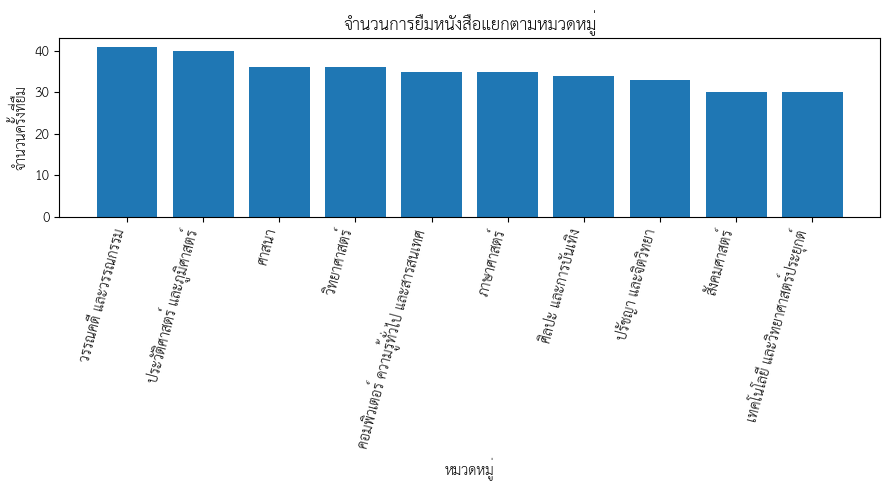

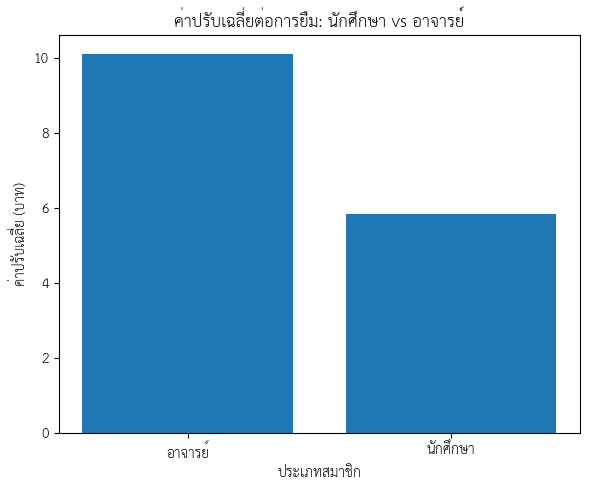

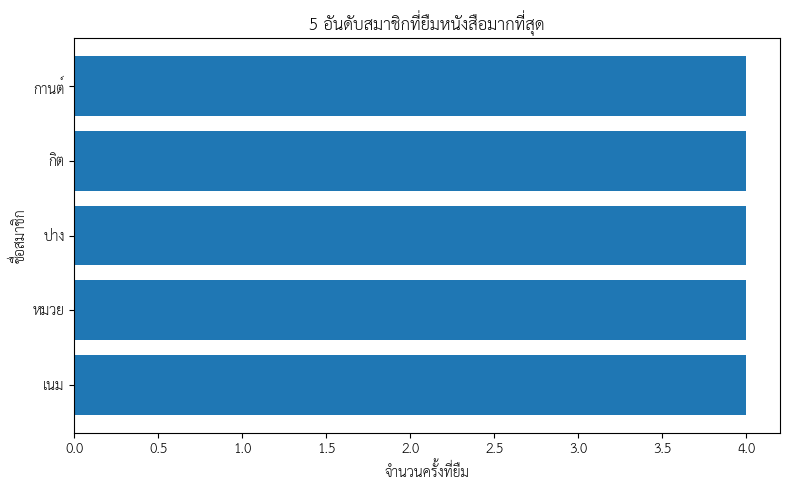

In [42]:
#สร้างกราฟ 3 รูป
import matplotlib.pyplot as plt
#กราฟที่ 1 — จำนวนการยืมตามหมวดหมู่
plt.figure(figsize=(9, 5))

plt.bar(
    category_summary["category_name"],
    category_summary["total_loans"]
)

plt.title("จำนวนการยืมหนังสือแยกตามหมวดหมู่")
plt.xlabel("หมวดหมู่")
plt.ylabel("จำนวนครั้งที่ยืม")

plt.xticks(
    rotation=75,
    ha="right"
)

plt.tight_layout()
plt.show()

#กราฟที่ 2 — ค่าปรับเฉลี่ยตามประเภทสมาชิก
plt.figure(figsize=(6, 5))

plt.bar(
    member_type_summary["member_type"],
    member_type_summary["avg_late_fee"]
)

plt.title("ค่าปรับเฉลี่ยต่อการยืม: นักศึกษา vs อาจารย์")
plt.xlabel("ประเภทสมาชิก")
plt.ylabel("ค่าปรับเฉลี่ย (บาท)")

plt.tight_layout()
plt.show()

#กราฟที่ 3 — Top 5 สมาชิกที่ยืมมากที่สุด
plt.figure(figsize=(8, 5))

plt.barh(
    top_members["name"],
    top_members["total_borrows"]
)

plt.title("5 อันดับสมาชิกที่ยืมหนังสือมากที่สุด")
plt.xlabel("จำนวนครั้งที่ยืม")
plt.ylabel("ชื่อสมาชิก")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()